<a href="https://colab.research.google.com/github/laodeazwaraiman/projekbelajar/blob/main/flight_delay_prediction_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Prediksi Keterlambatan Transportasi Menggunakan Machine Learning
## Berbasis Data Historis Perjalanan

**Dataset:** [US Flight Delays (USDOT) - Kaggle](https://www.kaggle.com/datasets/usdot/flight-delays)  
**Target Variable:** `ARRIVAL_DELAY` (menit)  
**Metode:** LightGBM, XGBoost, SGD Regressor + Hyperparameter Tuning  
**Split Rasio:** 80:20 | 70:30 | 90:10 (dijalankan per rasio)

---

## 0. Install & Import Dependencies

In [ ]:
# Install library yang diperlukan
!pip install lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, confusion_matrix, ConfusionMatrixDisplay)

import lightgbm as lgb
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor' : '#FFFFFF',
    'axes.grid'      : True,
    'grid.alpha'     : 0.4,
    'font.size'      : 11
})

SEED = 42
np.random.seed(SEED)
print(' Semua library berhasil diimport.')

 Semua library berhasil diimport.


---
## 1. Data Acquisition
Download dataset `flights.csv` dari Kaggle menggunakan API.

In [ ]:
# Setup Kaggle Credentials
from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dan ekstrak dataset
!kaggle datasets download usdot/flight-delays --unzip -p ./data/
print('✅ Dataset berhasil didownload.')

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/usdot/flight-delays
License(s): CC0-1.0
100% 191M/191M [00:02<00:00, 94.8MB/s]

✅ Dataset berhasil didownload.


---
## 2. 🔍 Data Understanding
Memahami struktur dataset `flights.csv`, tipe data, dan variabel target.

> **Catatan:** Hanya `flights.csv` yang digunakan dalam analisis ini. File `airlines.csv` dan `airports.csv` tidak digabungkan — semua fitur berasal murni dari `flights.csv`.

In [ ]:
flights_raw = pd.read_csv(
    './data/flights.csv',
    nrows=500000,          # ambil 500 ribu data saja
    engine='python',       # lebih aman untuk dataset besar
    on_bad_lines='skip'
)

print(f'Shape flights.csv : {flights_raw.shape}')
print(f'Kolom             : {list(flights_raw.columns)}')

Shape flights.csv : (500000, 31)
Kolom             : ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']


In [ ]:
# Preview 5 baris pertama
print('=== FLIGHTS – 5 baris pertama ===')
display(flights_raw.head())

print('\n=== INFO KOLOM ===')
flights_raw.info()

=== FLIGHTS – 5 baris pertama ===


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0000,-11.0000,21.0000,15.0000,205.0000,194.0000,169.0000,1448,404.0000,4.0000,430,408.0000,-22.0000,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0000,-8.0000,12.0000,14.0000,280.0000,279.0000,263.0000,2330,737.0000,4.0000,750,741.0000,-9.0000,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0000,-2.0000,16.0000,34.0000,286.0000,293.0000,266.0000,2296,800.0000,11.0000,806,811.0000,5.0000,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0000,-5.0000,15.0000,30.0000,285.0000,281.0000,258.0000,2342,748.0000,8.0000,805,756.0000,-9.0000,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0000,-1.0000,11.0000,35.0000,235.0000,215.0000,199.0000,1448,254.0000,5.0000,320,259.0000,-21.0000,0,0,NaN,NaN,NaN,NaN,NaN,NaN



=== INFO KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 500000 non-null  int64  
 1   MONTH                500000 non-null  int64  
 2   DAY                  500000 non-null  int64  
 3   DAY_OF_WEEK          500000 non-null  int64  
 4   AIRLINE              500000 non-null  object 
 5   FLIGHT_NUMBER        500000 non-null  int64  
 6   TAIL_NUMBER          496250 non-null  object 
 7   ORIGIN_AIRPORT       500000 non-null  object 
 8   DESTINATION_AIRPORT  500000 non-null  object 
 9   SCHEDULED_DEPARTURE  500000 non-null  int64  
 10  DEPARTURE_TIME       483584 non-null  float64
 11  DEPARTURE_DELAY      483584 non-null  float64
 12  TAXI_OUT             483296 non-null  float64
 13  WHEELS_OFF           483296 non-null  float64
 14  SCHEDULED_TIME       499999 non-null  float64
 1

In [ ]:
# Statistik deskriptif
print('=== STATISTIK DESKRIPTIF – flights.csv ===')
display(flights_raw.describe().T.style.background_gradient(cmap='Blues'))

=== STATISTIK DESKRIPTIF – flights.csv ===


,count,mean,std,min,25%,50%,75%,max
YEAR,500000.000000,2015.000000,0.000000,2015.000000,2015.000000,2015.000000,2015.000000,2015.000000
MONTH,500000.000000,1.060064,0.237606,1.000000,1.000000,1.000000,1.000000,2.000000
DAY,500000.000000,14.995424,9.320111,1.000000,7.000000,15.000000,23.000000,31.000000
DAY_OF_WEEK,500000.000000,4.006006,2.012339,1.000000,2.000000,4.000000,6.000000,7.000000
FLIGHT_NUMBER,500000.000000,2263.467272,1803.531769,1.000000,759.000000,1732.000000,3484.000000,9793.000000
SCHEDULED_DEPARTURE,500000.000000,1323.040278,468.226703,5.000000,925.000000,1320.000000,1720.000000,2359.000000
DEPARTURE_TIME,483584.000000,1332.957112,479.873381,1.000000,930.000000,1328.000000,1729.000000,2400.000000
DEPARTURE_DELAY,483584.000000,10.122653,37.720225,-48.000000,-5.000000,-1.000000,9.000000,1988.000000
TAXI_OUT,483296.000000,16.487865,9.671997,1.000000,11.000000,14.000000,19.000000,177.000000
WHEELS_OFF,483296.000000,1356.717620,479.846599,1.000000,946.000000,1342.000000,1742.000000,2400.000000


=== MISSING VALUES ===


,Missing Count,Missing (%)
CANCELLATION_REASON,483176,96.640000
SECURITY_DELAY,397701,79.540000
AIR_SYSTEM_DELAY,397701,79.540000
LATE_AIRCRAFT_DELAY,397701,79.540000
WEATHER_DELAY,397701,79.540000
AIRLINE_DELAY,397701,79.540000
ARRIVAL_DELAY,17948,3.590000
ELAPSED_TIME,17948,3.590000
AIR_TIME,17948,3.590000
TAXI_IN,17159,3.430000


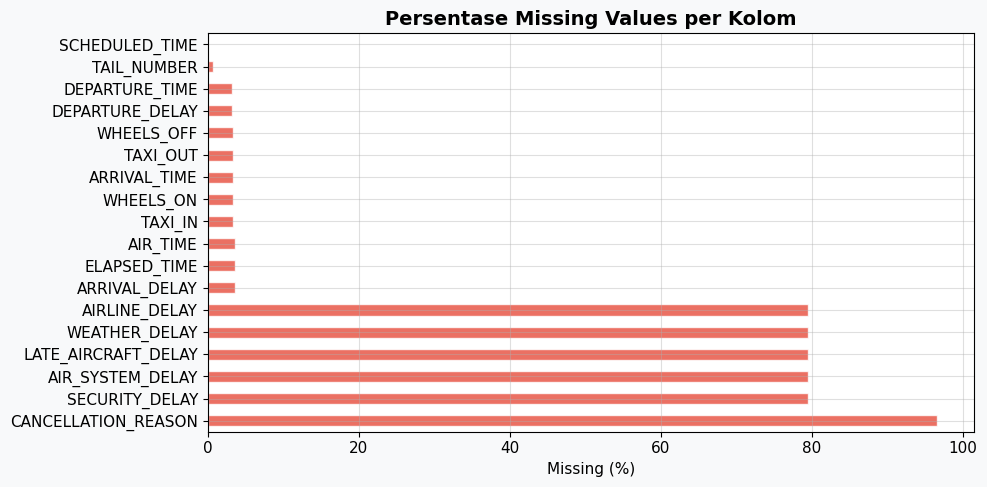

In [ ]:
# Distribusi missing values
missing     = flights_raw.isnull().sum()
missing_pct = (missing / len(flights_raw) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

print('=== MISSING VALUES ===')
display(missing_df.style.bar(subset=['Missing (%)'], color='#E74C3C'))

fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Missing (%)'].plot(kind='barh', ax=ax, color='#E74C3C', alpha=0.8, edgecolor='white')
ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing (%)')
plt.tight_layout()
plt.show()

---
## 3. Data Cleaning
Menghapus penerbangan yang dibatalkan/dialihkan, menangani missing values pada target, dan filter outlier ekstrim.

In [ ]:
df = flights_raw.copy()
print(f'Jumlah baris awal               : {len(df):,}')

# 1. Hapus penerbangan yang dibatalkan
df = df[df['CANCELLED'] == 0].copy()
print(f'Setelah hapus cancelled          : {len(df):,}')

# 2. Hapus penerbangan yang dialihkan
df = df[df['DIVERTED'] == 0].copy()
print(f'Setelah hapus diverted           : {len(df):,}')

# 3. Hapus baris tanpa ARRIVAL_DELAY (variabel target)
df = df.dropna(subset=['ARRIVAL_DELAY'])
print(f'Setelah hapus missing target     : {len(df):,}')

# 4. Hapus kolom tidak relevan / bocor data (data leakage)
drop_cols = [
    'CANCELLED', 'CANCELLATION_REASON', 'DIVERTED',
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY',  # komponen delay (bocor)
    'FLIGHT_NUMBER', 'TAIL_NUMBER',           # ID, high cardinality
    'ARRIVAL_TIME',                            # terjadi setelah landing
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# 5. Filter outlier ARRIVAL_DELAY yang sangat ekstrim (> 24 jam)
df = df[(df['ARRIVAL_DELAY'] > -120) & (df['ARRIVAL_DELAY'] < 1440)]
print(f'Setelah filter outlier delay     : {len(df):,}')

# 6. Hapus sisa missing values
df.dropna(inplace=True)
print(f'Setelah hapus missing lainnya    : {len(df):,}')

# Sampling untuk efisiensi komputasi (aktifkan jika RAM terbatas)
# df = df.sample(n=500_000, random_state=SEED).reset_index(drop=True)

print(f'\n✅ Data bersih: {df.shape}')
print(f'Kolom tersisa : {list(df.columns)}')

Jumlah baris awal               : 500,000
Setelah hapus cancelled          : 483,176
Setelah hapus diverted           : 482,052
Setelah hapus missing target     : 482,052
Setelah filter outlier delay     : 482,047
Setelah hapus missing lainnya    : 482,047

✅ Data bersih: (482047, 20)
Kolom tersisa : ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY']


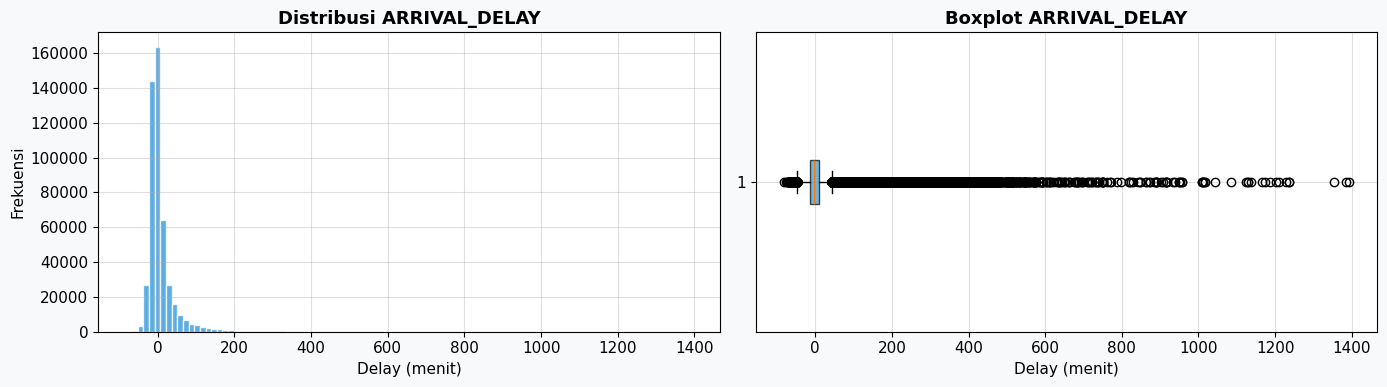

count   482047.0000
mean         6.2130
std         40.1629
min        -82.0000
25%        -13.0000
50%         -4.0000
75%         10.0000
max       1392.0000
Name: ARRIVAL_DELAY, dtype: float64


In [ ]:
# Visualisasi distribusi target ARRIVAL_DELAY
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['ARRIVAL_DELAY'], bins=100, color='#3498DB', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribusi ARRIVAL_DELAY', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delay (menit)')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(df['ARRIVAL_DELAY'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3498DB', alpha=0.7))
axes[1].set_title('Boxplot ARRIVAL_DELAY', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Delay (menit)')

plt.tight_layout()
plt.show()
print(df['ARRIVAL_DELAY'].describe())

---
## 4. Feature Engineering
Membuat fitur baru berbasis waktu dan transformasi variabel dari `flights.csv`.

In [ ]:
def extract_time_features(df):
    """
    Mengekstrak fitur waktu dari kolom numerik SCHEDULED_DEPARTURE & SCHEDULED_ARRIVAL.
    Format: HHMM (misal 1305 = jam 13, menit 05).
    Semua fitur berasal murni dari flights.csv.
    """
    df = df.copy()

    # --- Fitur dari tanggal ---
    df['IS_WEEKEND'] = (df['DAY_OF_WEEK'] >= 6).astype(int)
    df['QUARTER']    = pd.cut(df['MONTH'], bins=[0,3,6,9,12],
                               labels=[1,2,3,4]).astype(int)
    df['IS_HOLIDAY_MONTH'] = df['MONTH'].isin([6, 7, 8, 11, 12]).astype(int)

    # --- Fitur dari SCHEDULED_DEPARTURE ---
    dep = df['SCHEDULED_DEPARTURE'].fillna(0).astype(int)
    df['DEP_HOUR']   = dep // 100
    df['DEP_MINUTE'] = dep % 100
    df['DEP_PERIOD'] = pd.cut(
        df['DEP_HOUR'],
        bins=[-1, 5, 11, 17, 21, 24],
        labels=['latenight','morning','afternoon','evening','night']
    ).astype('category').cat.codes
    # Siklus waktu sin/cos agar jam 0 dan 23 berdekatan
    df['DEP_SIN'] = np.sin(2 * np.pi * df['DEP_HOUR'] / 24)
    df['DEP_COS'] = np.cos(2 * np.pi * df['DEP_HOUR'] / 24)

    # --- Fitur dari SCHEDULED_ARRIVAL ---
    arr = df['SCHEDULED_ARRIVAL'].fillna(0).astype(int)
    df['ARR_HOUR']   = arr // 100
    df['ARR_MINUTE'] = arr % 100
    df['ARR_SIN']    = np.sin(2 * np.pi * df['ARR_HOUR'] / 24)
    df['ARR_COS']    = np.cos(2 * np.pi * df['ARR_HOUR'] / 24)

    # --- Fitur Kecepatan dari flights.csv ---
    if 'SCHEDULED_TIME' in df.columns and 'DISTANCE' in df.columns:
        df['SPEED_ESTIMATE'] = (
            df['DISTANCE'] / (df['SCHEDULED_TIME'].replace(0, np.nan) / 60)
        )
        df['SPEED_ESTIMATE'].fillna(df['SPEED_ESTIMATE'].median(), inplace=True)

    # --- Rute: ORIGIN + DESTINATION (dari flights.csv) ---
    if 'ORIGIN_AIRPORT' in df.columns and 'DESTINATION_AIRPORT' in df.columns:
        df['ROUTE'] = (
            df['ORIGIN_AIRPORT'].astype(str) + '-' +
            df['DESTINATION_AIRPORT'].astype(str)
        )

    # --- Jenis penerbangan berdasarkan jarak ---
    if 'DISTANCE' in df.columns:
        df['FLIGHT_TYPE'] = pd.cut(
            df['DISTANCE'],
            bins=[0, 500, 1500, 99999],
            labels=[0, 1, 2]  # Short=0, Medium=1, Long=2
        ).astype('category').cat.codes

    return df

df = extract_time_features(df)
print(f'✅ Fitur baru ditambahkan. Shape: {df.shape}')
new_cols = ['IS_WEEKEND','QUARTER','IS_HOLIDAY_MONTH','DEP_HOUR','DEP_MINUTE',
            'DEP_PERIOD','DEP_SIN','DEP_COS','ARR_HOUR','ARR_MINUTE',
            'ARR_SIN','ARR_COS','SPEED_ESTIMATE','ROUTE','FLIGHT_TYPE']
print('Kolom baru:', [c for c in new_cols if c in df.columns])

✅ Fitur baru ditambahkan. Shape: (482047, 35)
Kolom baru: ['IS_WEEKEND', 'QUARTER', 'IS_HOLIDAY_MONTH', 'DEP_HOUR', 'DEP_MINUTE', 'DEP_PERIOD', 'DEP_SIN', 'DEP_COS', 'ARR_HOUR', 'ARR_MINUTE', 'ARR_SIN', 'ARR_COS', 'SPEED_ESTIMATE', 'ROUTE', 'FLIGHT_TYPE']


---
## 5. Exploratory Data Analysis (EDA)
Analisis distribusi, korelasi, dan tren keterlambatan.

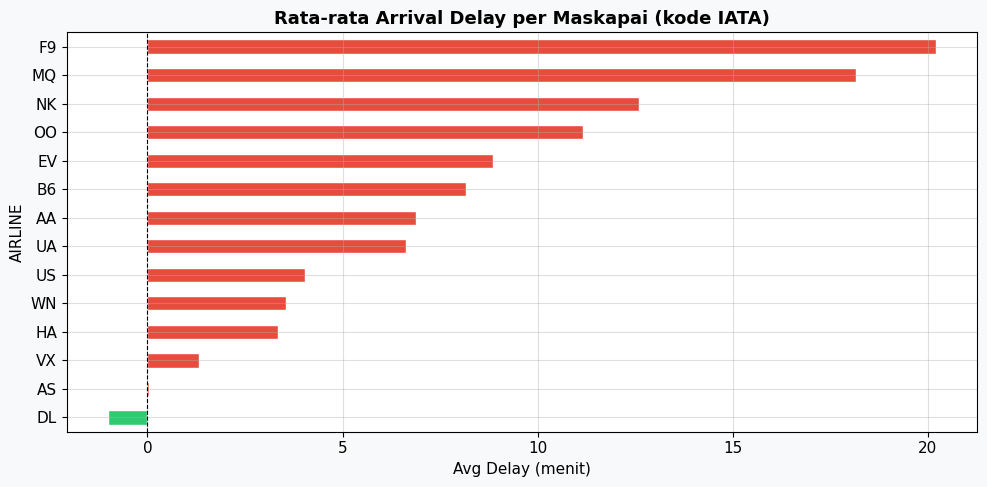

In [ ]:
# --- Plot 1: Rata-rata delay per maskapai ---
airline_delay = df.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in airline_delay.values]
airline_delay.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rata-rata Arrival Delay per Maskapai (kode IATA)', fontsize=13, fontweight='bold')
ax.set_xlabel('Avg Delay (menit)')
plt.tight_layout()
plt.show()

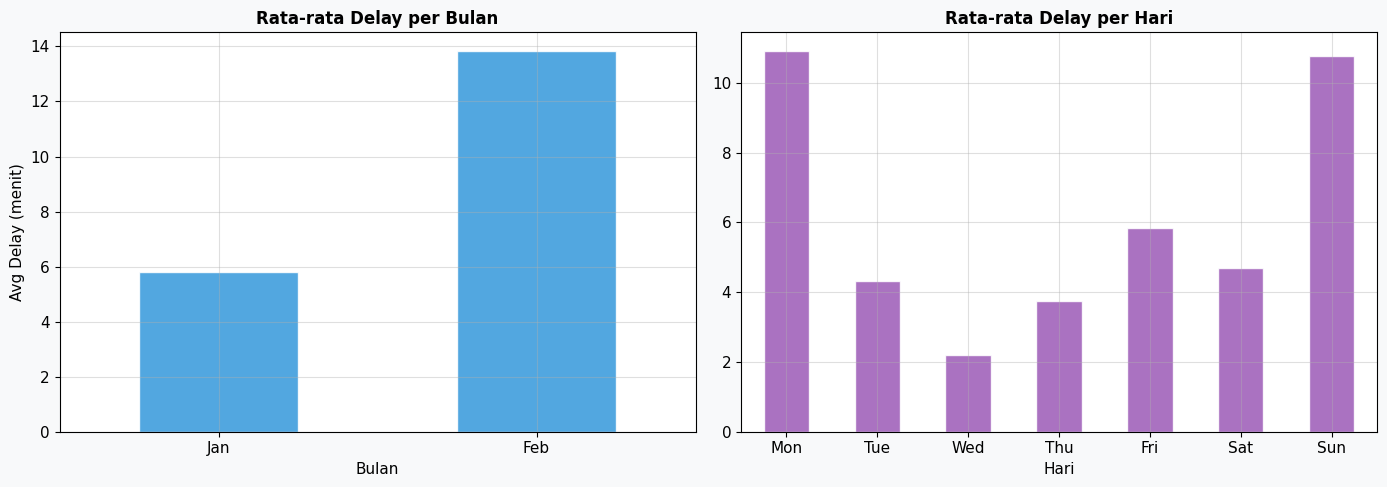

In [ ]:
# --- Plot 2: Delay per bulan dan hari dalam seminggu ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
day_names   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

monthly_delay = df.groupby('MONTH')['ARRIVAL_DELAY'].mean()
monthly_delay.index = month_names[:len(monthly_delay)]
monthly_delay.plot(kind='bar', ax=axes[0], color='#3498DB', alpha=0.85, edgecolor='white')
axes[0].set_title('Rata-rata Delay per Bulan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Avg Delay (menit)')
axes[0].tick_params(axis='x', rotation=0)

daily_delay = df.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean()
daily_delay.index = day_names[:len(daily_delay)]
daily_delay.plot(kind='bar', ax=axes[1], color='#9B59B6', alpha=0.85, edgecolor='white')
axes[1].set_title('Rata-rata Delay per Hari', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hari')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

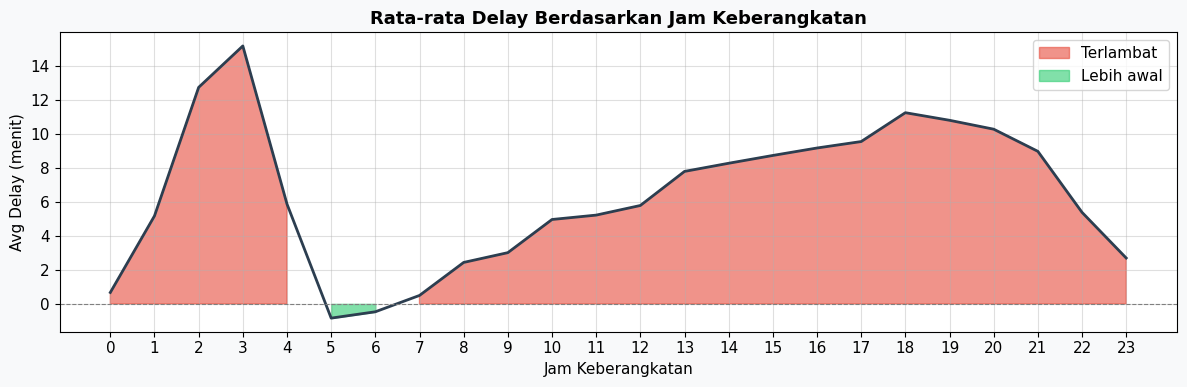

In [ ]:
# --- Plot 3: Delay per jam keberangkatan ---
hour_delay = df.groupby('DEP_HOUR')['ARRIVAL_DELAY'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(hour_delay.index, hour_delay.values,
                where=(hour_delay.values > 0),  alpha=0.6, color='#E74C3C', label='Terlambat')
ax.fill_between(hour_delay.index, hour_delay.values,
                where=(hour_delay.values <= 0), alpha=0.6, color='#2ECC71', label='Lebih awal')
ax.plot(hour_delay.index, hour_delay.values, color='#2C3E50', linewidth=2)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Rata-rata Delay Berdasarkan Jam Keberangkatan', fontsize=13, fontweight='bold')
ax.set_xlabel('Jam Keberangkatan')
ax.set_ylabel('Avg Delay (menit)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

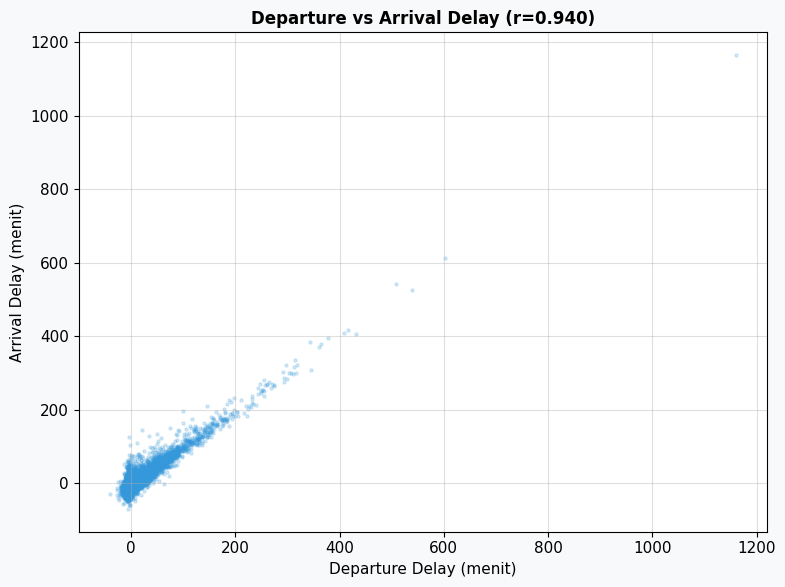

In [ ]:
# --- Plot 4: Scatter DEPARTURE_DELAY vs ARRIVAL_DELAY ---
sample_eda = df.sample(min(10000, len(df)), random_state=SEED)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample_eda['DEPARTURE_DELAY'], sample_eda['ARRIVAL_DELAY'],
           alpha=0.2, s=5, color='#3498DB')
corr = sample_eda['DEPARTURE_DELAY'].corr(sample_eda['ARRIVAL_DELAY'])
ax.set_title(f'Departure vs Arrival Delay (r={corr:.3f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Departure Delay (menit)')
ax.set_ylabel('Arrival Delay (menit)')
plt.tight_layout()
plt.show()

---
## 6. Feature Selection & Encoding
Memilih fitur yang relevan dari `flights.csv` dan encoding variabel kategorik.

In [ ]:
# Fitur yang dipilih — semuanya dari flights.csv
FEATURE_COLS = [
    # Waktu & Kalender
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'IS_WEEKEND', 'QUARTER', 'IS_HOLIDAY_MONTH',
    # Keberangkatan
    'DEP_HOUR', 'DEP_MINUTE', 'DEP_PERIOD', 'DEP_SIN', 'DEP_COS',
    # Kedatangan
    'ARR_HOUR', 'ARR_MINUTE', 'ARR_SIN', 'ARR_COS',
    # Penerbangan (dari flights.csv)
    'SCHEDULED_TIME', 'DISTANCE', 'DEPARTURE_DELAY',
    'TAXI_OUT', 'TAXI_IN', 'ELAPSED_TIME',
    # Fitur turunan dari flights.csv
    'SPEED_ESTIMATE', 'FLIGHT_TYPE',
    # Kategorikal dari flights.csv
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE',
]

TARGET_COL = 'ARRIVAL_DELAY'

# Hanya gunakan kolom yang ada dalam df
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f'Fitur terpilih ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'  - {f}')

df_model = df[FEATURE_COLS + [TARGET_COL]].copy()

Fitur terpilih (27):
  - MONTH
  - DAY
  - DAY_OF_WEEK
  - IS_WEEKEND
  - QUARTER
  - IS_HOLIDAY_MONTH
  - DEP_HOUR
  - DEP_MINUTE
  - DEP_PERIOD
  - DEP_SIN
  - DEP_COS
  - ARR_HOUR
  - ARR_MINUTE
  - ARR_SIN
  - ARR_COS
  - SCHEDULED_TIME
  - DISTANCE
  - DEPARTURE_DELAY
  - TAXI_OUT
  - TAXI_IN
  - ELAPSED_TIME
  - SPEED_ESTIMATE
  - FLIGHT_TYPE
  - AIRLINE
  - ORIGIN_AIRPORT
  - DESTINATION_AIRPORT
  - ROUTE


In [ ]:
# Label Encoding untuk fitur kategorik
cat_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Kolom kategorik yang di-encode: {cat_cols}')

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col]  = le
    print(f'  ✅ {col}: {len(le.classes_)} kelas')

print(f'\n✅ Encoding selesai. Shape: {df_model.shape}')
display(df_model.head(3))

Kolom kategorik yang di-encode: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']
  ✅ AIRLINE: 14 kelas
  ✅ ORIGIN_AIRPORT: 313 kelas
  ✅ DESTINATION_AIRPORT: 313 kelas
  ✅ ROUTE: 4174 kelas

✅ Encoding selesai. Shape: (482047, 28)


,MONTH,DAY,DAY_OF_WEEK,IS_WEEKEND,QUARTER,IS_HOLIDAY_MONTH,DEP_HOUR,DEP_MINUTE,DEP_PERIOD,DEP_SIN,DEP_COS,ARR_HOUR,ARR_MINUTE,ARR_SIN,ARR_COS,SCHEDULED_TIME,DISTANCE,DEPARTURE_DELAY,TAXI_OUT,TAXI_IN,ELAPSED_TIME,SPEED_ESTIMATE,FLIGHT_TYPE,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ROUTE,ARRIVAL_DELAY
0,1,1,4,0,1,0,0,5,0,0.0000,1.0000,4,30,0.8660,0.5000,205.0000,1448,-11.0000,21.0000,4.0000,194.0000,423.8049,1,1,15,269,78,-22.0000
1,1,1,4,0,1,0,0,10,0,0.0000,1.0000,7,50,0.9659,-0.2588,280.0000,2330,-8.0000,12.0000,4.0000,279.0000,499.2857,2,0,169,227,2217,-9.0000
2,1,1,4,0,1,0,0,20,0,0.0000,1.0000,8,6,0.8660,-0.5000,286.0000,2296,-2.0000,16.0000,11.0000,293.0000,481.6783,2,11,270,63,3704,5.0000


---
## 7. Heatmap Korelasi – Fitur Paling Berpengaruh
Menganalisis fitur mana yang paling berkorelasi terhadap `ARRIVAL_DELAY`.

🔝 Top 20 Fitur Paling Berkorelasi dengan ARRIVAL_DELAY:
DEPARTURE_DELAY    0.9398
TAXI_OUT           0.2581
DAY               -0.1727
TAXI_IN            0.1655
DEP_SIN           -0.0882
DEP_HOUR           0.0814
ARR_SIN           -0.0786
ARR_HOUR           0.0766
DEP_PERIOD         0.0716
ARR_COS            0.0638
MONTH              0.0443
SCHEDULED_TIME    -0.0406
DISTANCE          -0.0325
ELAPSED_TIME       0.0305
FLIGHT_TYPE       -0.0294
IS_WEEKEND         0.0256
SPEED_ESTIMATE    -0.0133
ROUTE              0.0125
DEP_MINUTE         0.0117
ORIGIN_AIRPORT     0.0116


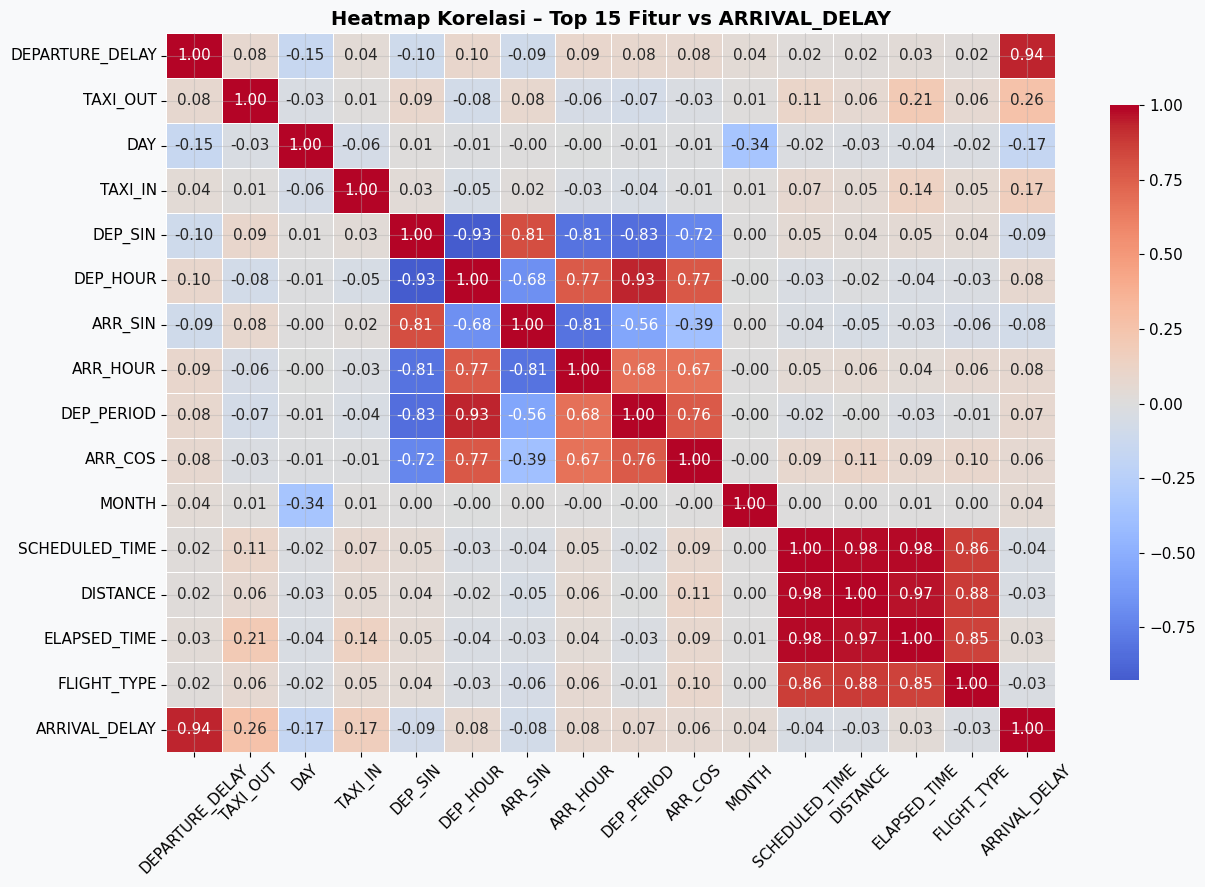

In [ ]:
# ── Korelasi Pearson terhadap target ──
corr_target = df_model.corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)

print('🔝 Top 20 Fitur Paling Berkorelasi dengan ARRIVAL_DELAY:')
print(corr_target.head(20).to_string())

# ── Heatmap 1: Top 15 fitur + target ──
top15 = corr_target.abs().nlargest(15).index.tolist()
corr_matrix = df_model[top15 + [TARGET_COL]].corr()

fig, ax = plt.subplots(figsize=(13, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',      # ubah warna biar seperti gambar
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Heatmap Korelasi – Top 15 Fitur vs ARRIVAL_DELAY',
             fontsize=14, fontweight='bold')

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

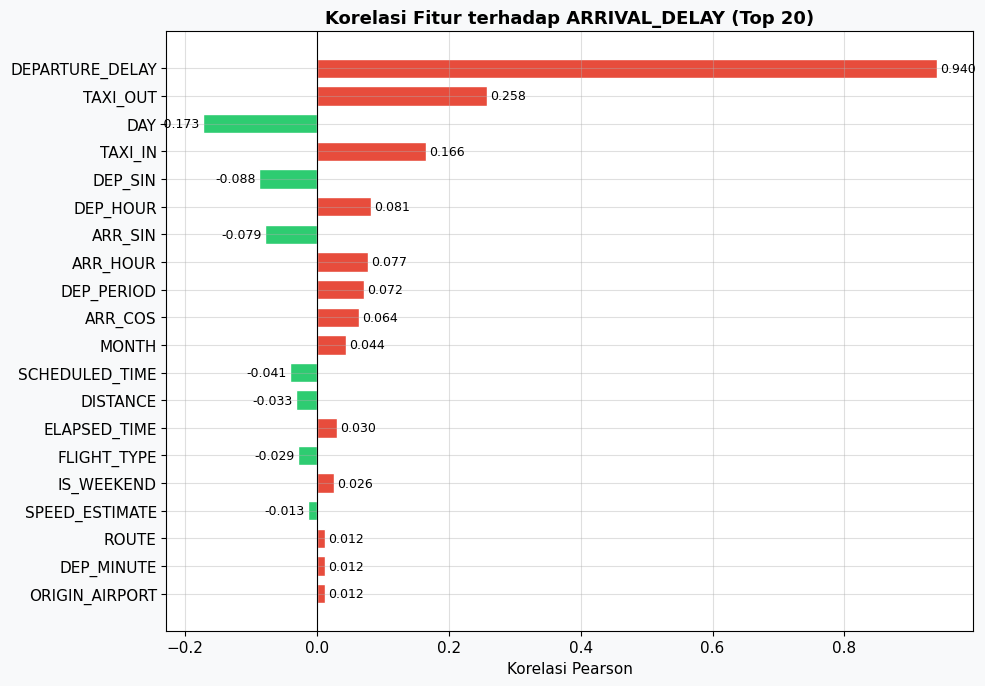

In [ ]:
# ── Heatmap 2: Bar korelasi terhadap target ──
top20_corr = corr_target.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in top20_corr.values]
bars = ax.barh(top20_corr.index[::-1], top20_corr.values[::-1],
               color=colors[::-1], edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur terhadap ARRIVAL_DELAY (Top 20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Korelasi Pearson')
for bar, val in zip(bars, top20_corr.values[::-1]):
    ax.text(
        val + 0.005 if val >= 0 else val - 0.005,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9
    )
plt.tight_layout()
plt.show()

---
## 8. Data Splitting
Tiga rasio split dijalankan **satu per satu** — setiap split memiliki siklus training dan evaluasi tersendiri:

| Rasio | Train | Test |
|-------|-------|------|
| **80:20** | 80% | 20% |
| **70:30** | 70% | 30% |
| **90:10** | 90% | 10% |

> Fungsi evaluasi, modeling, confusion matrix, dan perbandingan diulang untuk **setiap split**.

In [ ]:
X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL]

print(f'Total data : {len(X):,} baris | {X.shape[1]} fitur')
print(f'Fitur      : {list(X.columns)}')

Total data : 482,047 baris | 27 fitur
Fitur      : ['MONTH', 'DAY', 'DAY_OF_WEEK', 'IS_WEEKEND', 'QUARTER', 'IS_HOLIDAY_MONTH', 'DEP_HOUR', 'DEP_MINUTE', 'DEP_PERIOD', 'DEP_SIN', 'DEP_COS', 'ARR_HOUR', 'ARR_MINUTE', 'ARR_SIN', 'ARR_COS', 'SCHEDULED_TIME', 'DISTANCE', 'DEPARTURE_DELAY', 'TAXI_OUT', 'TAXI_IN', 'ELAPSED_TIME', 'SPEED_ESTIMATE', 'FLIGHT_TYPE', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']


In [ ]:
# ── Fungsi Helper ──
def make_split(X, y, test_size, seed=SEED):
    """Split dan scale dalam satu langkah."""
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=seed)
    sc  = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc = sc.transform(Xte)
    return Xtr, Xte, ytr, yte, Xtr_sc, Xte_sc, sc


def evaluate_model(name, y_true, y_pred):
    """Menghitung dan menampilkan metrik regresi."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)

    print(f'\n{"="*45}')
    print(f'  Model : {name}')
    print(f'  RMSE  : {rmse:.4f} menit')
    print(f'  MAE   : {mae:.4f} menit')
    print(f'  MAPE  : {mape:.2f} %')
    print(f'  R²    : {r2:.4f}')
    print(f'{"="*45}')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'R2': r2}


def delay_category(val):
    """Kategorikan nilai delay ke 4 kelas."""
    if val <= 0:   return 0  # On-time / early
    elif val <= 15: return 1  # Ringan
    elif val <= 60: return 2  # Sedang
    else:           return 3  # Parah

DELAY_LABELS = ['On-Time/Early', 'Ringan (≤15m)', 'Sedang (≤60m)', 'Parah (>60m)']

print('Fungsi helper siap.')

Fungsi helper siap.


---
## 9. Modeling – Split 80:20
Training dan evaluasi ketiga model pada rasio **80% train / 20% test**.

In [ ]:
# ── Split 80:20 ──
SPLIT_LABEL = '80:20'
X_train, X_test, y_train, y_test, X_train_sc, X_test_sc, scaler_80 = make_split(X, y, test_size=0.20)

print(f'Split {SPLIT_LABEL}')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')

Split 80:20
  X_train : (385637, 27)
  X_test  : (96410, 27)
  y_train : (385637,)
  y_test  : (96410,)


### 9.1 LightGBM – 80:20

In [ ]:
lgb_80 = lgb.LGBMRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 8,
    num_leaves       = 63,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_samples= 50,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    random_state     = SEED,
    n_jobs           = -1,
    verbose          = -1
)
lgb_80.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=100)]
)
y_pred_lgb_80 = lgb_80.predict(X_test)
results_80 = [evaluate_model('LightGBM', y_test, y_pred_lgb_80)]

[100]	valid_0's l2: 55.356
[200]	valid_0's l2: 26.4906
[300]	valid_0's l2: 18.2032
[400]	valid_0's l2: 15.1528
[500]	valid_0's l2: 13.6943

  Model : LightGBM
  RMSE  : 3.7006 menit
  MAE   : 1.3975 menit
  MAPE  : 17.50 %
  R²    : 0.9916


### 9.2 XGBoost – 80:20

In [ ]:
xgb_80 = xgb.XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 7,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 50,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = SEED,
    tree_method      = 'hist',
    n_jobs           = -1,
    verbosity        = 0
)
xgb_80.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
y_pred_xgb_80 = xgb_80.predict(X_test)
results_80.append(evaluate_model('XGBoost', y_test, y_pred_xgb_80))

[0]	validation_0-rmse:40.11257
[100]	validation_0-rmse:11.67145
[200]	validation_0-rmse:10.24955
[300]	validation_0-rmse:9.80422
[400]	validation_0-rmse:9.62061
[499]	validation_0-rmse:9.55946

  Model : XGBoost
  RMSE  : 9.5595 menit
  MAE   : 2.0832 menit
  MAPE  : 22.04 %
  R²    : 0.9437


### 9.3 SGD Regressor – 80:20

In [ ]:
sgd_80 = SGDRegressor(
    loss              = 'huber',
    penalty           = 'elasticnet',
    alpha             = 0.001,
    l1_ratio          = 0.15,
    max_iter          = 1000,
    tol               = 1e-4,
    random_state      = SEED,
    early_stopping    = True,
    validation_fraction=0.1,
    n_iter_no_change  = 10
)
sgd_80.fit(X_train_sc, y_train)
y_pred_sgd_80 = sgd_80.predict(X_test_sc)
results_80.append(evaluate_model('SGD Regressor', y_test, y_pred_sgd_80))


  Model : SGD Regressor
  RMSE  : 14.1134 menit
  MAE   : 8.9127 menit
  MAPE  : 86.85 %
  R²    : 0.8772


### 9.4 Evaluasi & Visualisasi – 80:20

In [ ]:
# Tabel performa split 80:20
df_80 = pd.DataFrame(results_80).set_index('Model')
print('=== PERFORMA MODEL – Split 80:20 ===')
display(df_80.style
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE','MAE','MAPE (%)'])
    .background_gradient(cmap='RdYlGn',   subset=['R2'])
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','MAPE (%)':'{:.2f}','R2':'{:.4f}'})
)

=== PERFORMA MODEL – Split 80:20 ===


,RMSE,MAE,MAPE (%),R2
Model,,,,
LightGBM,3.7006,1.3975,17.50,0.9916
XGBoost,9.5595,2.0832,22.04,0.9437
SGD Regressor,14.1134,8.9127,86.85,0.8772


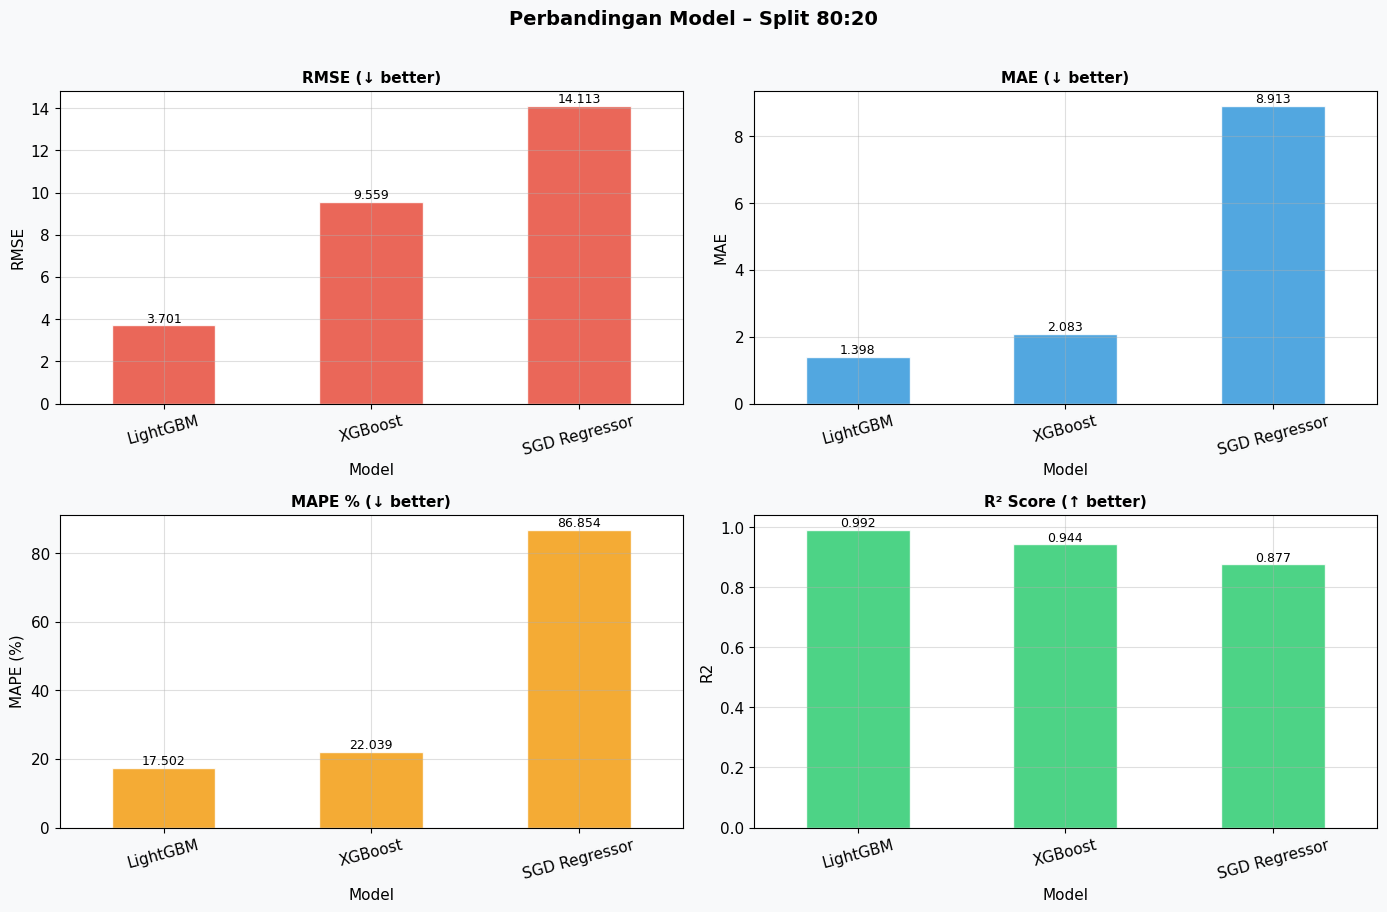

In [ ]:
# Bar chart split 80:20
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = ['RMSE', 'MAE', 'MAPE (%)', 'R2']
colors  = ['#E74C3C','#3498DB','#F39C12','#2ECC71']
titles  = ['RMSE (↓ better)','MAE (↓ better)','MAPE % (↓ better)','R² Score (↑ better)']

for ax, metric, color, title in zip(axes.flat, metrics, colors, titles):
    df_80[metric].plot(kind='bar', ax=ax, color=color, alpha=0.85, edgecolor='white', rot=15)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Perbandingan Model – Split 80:20', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

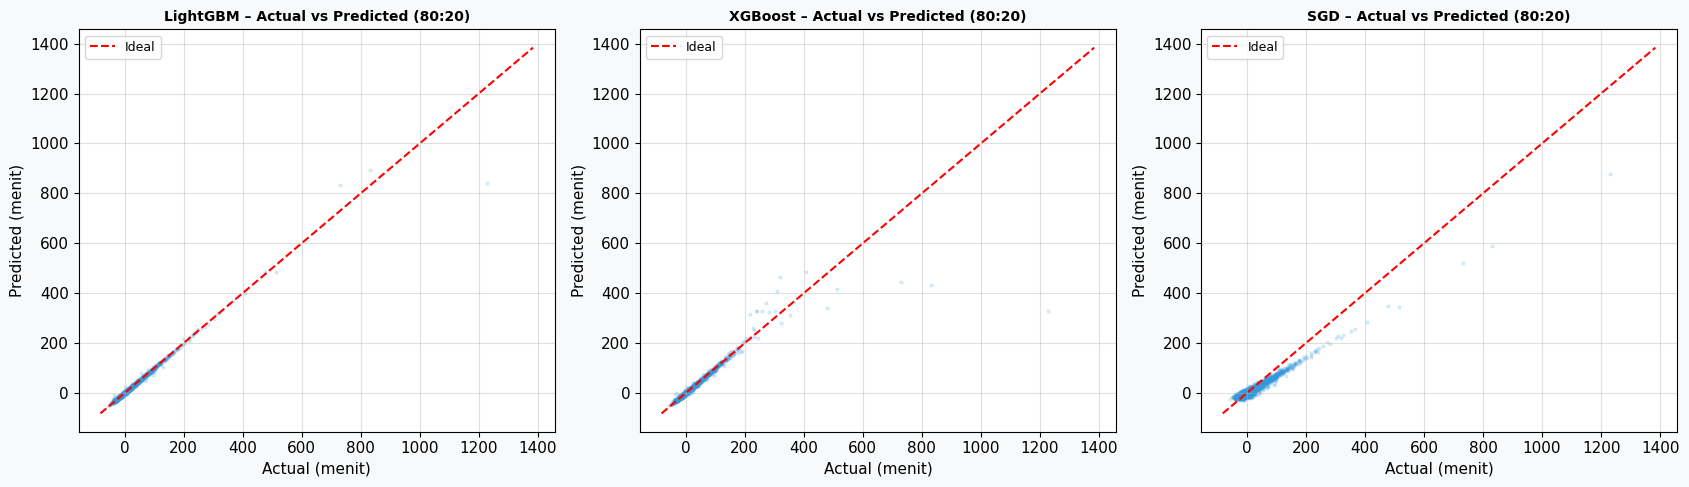

In [ ]:
# Actual vs Predicted – Split 80:20
sample_n = min(5000, len(y_test))
idx = np.random.choice(len(y_test), sample_n, replace=False)
y_test_arr = np.array(y_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
preds_80 = [('LightGBM', y_pred_lgb_80), ('XGBoost', y_pred_xgb_80), ('SGD', y_pred_sgd_80)]

for ax, (name, y_pred) in zip(axes, preds_80):
    ax.scatter(y_test_arr[idx], y_pred[idx], alpha=0.15, s=4, color='#3498DB')
    lims = [min(y_test_arr.min(), y_pred.min()), max(y_test_arr.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
    ax.set_title(f'{name} – Actual vs Predicted (80:20)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual (menit)')
    ax.set_ylabel('Predicted (menit)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

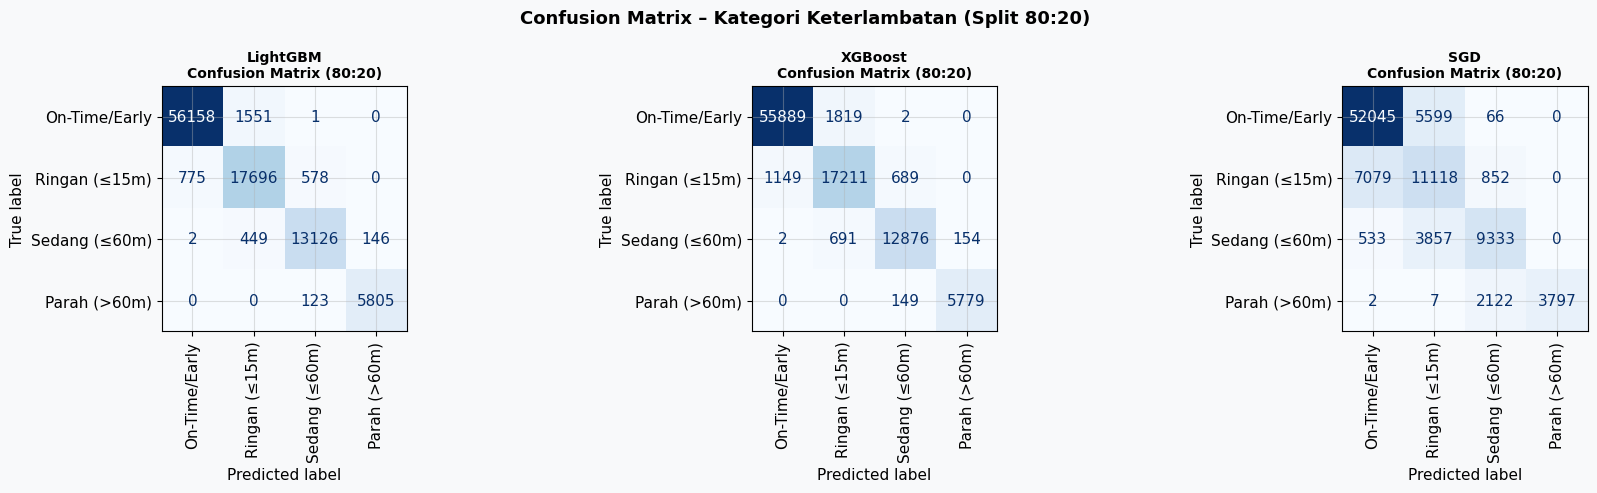

In [ ]:
# Confusion Matrix Kategori Delay – Split 80:20
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, preds_80):
    yc_true = np.array([delay_category(v) for v in y_test])
    yc_pred = np.array([delay_category(v) for v in y_pred])
    cm = confusion_matrix(yc_true, yc_pred, labels=[0,1,2,3])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DELAY_LABELS)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation='vertical')
    ax.set_title(f'{name}\nConfusion Matrix (80:20)', fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrix – Kategori Keterlambatan (Split 80:20)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Modeling – Split 70:30
Training dan evaluasi ketiga model pada rasio **70% train / 30% test**.

In [ ]:
# ── Split 70:30 ──
SPLIT_LABEL = '70:30'
X_train, X_test, y_train, y_test, X_train_sc, X_test_sc, scaler_70 = make_split(X, y, test_size=0.30)

print(f'Split {SPLIT_LABEL}')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')

Split 70:30
  X_train : (337432, 27)
  X_test  : (144615, 27)
  y_train : (337432,)
  y_test  : (144615,)


### 10.1 LightGBM – 70:30

In [ ]:
lgb_70 = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=8, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
    reg_alpha=0.1, reg_lambda=0.1, random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_70.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=100)]
)
y_pred_lgb_70 = lgb_70.predict(X_test)
results_70 = [evaluate_model('LightGBM', y_test, y_pred_lgb_70)]

[100]	valid_0's l2: 56.1167
[200]	valid_0's l2: 28.9274
[300]	valid_0's l2: 21.1991
[400]	valid_0's l2: 18.2599
[500]	valid_0's l2: 17.0438

  Model : LightGBM
  RMSE  : 4.1284 menit
  MAE   : 1.4049 menit
  MAPE  : 17.49 %
  R²    : 0.9896


### 10.2 XGBoost – 70:30

In [ ]:
xgb_70 = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=7, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=50, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, tree_method='hist', n_jobs=-1, verbosity=0
)
xgb_70.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
y_pred_xgb_70 = xgb_70.predict(X_test)
results_70.append(evaluate_model('XGBoost', y_test, y_pred_xgb_70))

[0]	validation_0-rmse:40.25199
[100]	validation_0-rmse:12.01557
[200]	validation_0-rmse:10.67961
[300]	validation_0-rmse:10.26469
[400]	validation_0-rmse:10.08886
[499]	validation_0-rmse:10.02358

  Model : XGBoost
  RMSE  : 10.0236 menit
  MAE   : 2.1151 menit
  MAPE  : 22.23 %
  R²    : 0.9385


### 10.3 SGD Regressor – 70:30

In [ ]:
sgd_70 = SGDRegressor(
    loss='huber', penalty='elasticnet', alpha=0.001, l1_ratio=0.15,
    max_iter=1000, tol=1e-4, random_state=SEED,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=10
)
sgd_70.fit(X_train_sc, y_train)
y_pred_sgd_70 = sgd_70.predict(X_test_sc)
results_70.append(evaluate_model('SGD Regressor', y_test, y_pred_sgd_70))


  Model : SGD Regressor
  RMSE  : 14.4139 menit
  MAE   : 9.0261 menit
  MAPE  : 87.05 %
  R²    : 0.8729


### 10.4 Evaluasi & Visualisasi – 70:30

In [ ]:
df_70 = pd.DataFrame(results_70).set_index('Model')
print('=== PERFORMA MODEL – Split 70:30 ===')
display(df_70.style
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE','MAE','MAPE (%)'])
    .background_gradient(cmap='RdYlGn',   subset=['R2'])
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','MAPE (%)':'{:.2f}','R2':'{:.4f}'})
)

=== PERFORMA MODEL – Split 70:30 ===


,RMSE,MAE,MAPE (%),R2
Model,,,,
LightGBM,4.1284,1.4049,17.49,0.9896
XGBoost,10.0236,2.1151,22.23,0.9385
SGD Regressor,14.4139,9.0261,87.05,0.8729


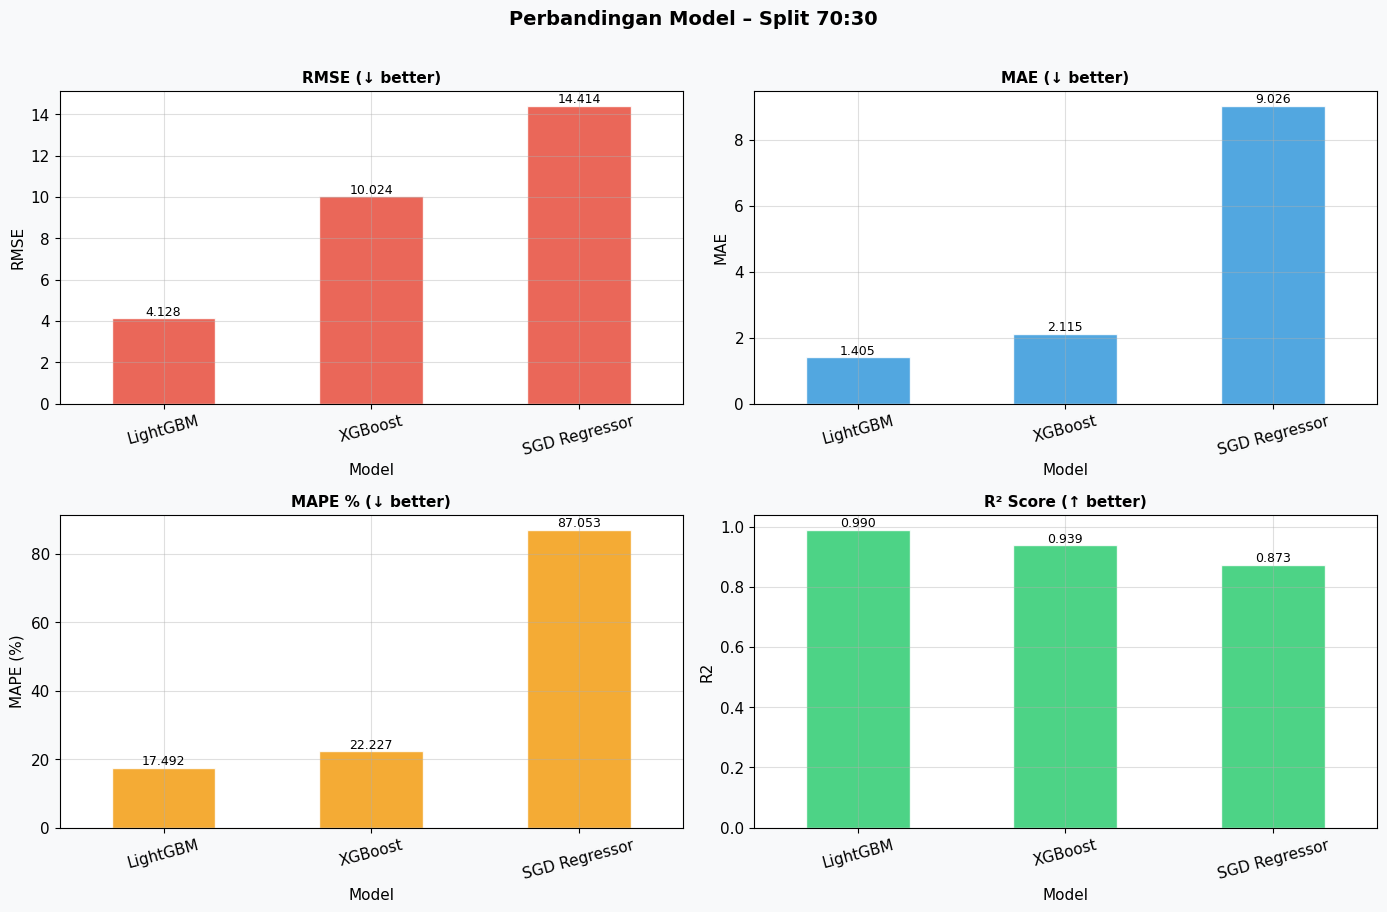

In [ ]:
# Bar chart split 70:30
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric, color, title in zip(axes.flat, metrics, colors, titles):
    df_70[metric].plot(kind='bar', ax=ax, color=color, alpha=0.85, edgecolor='white', rot=15)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Perbandingan Model – Split 70:30', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

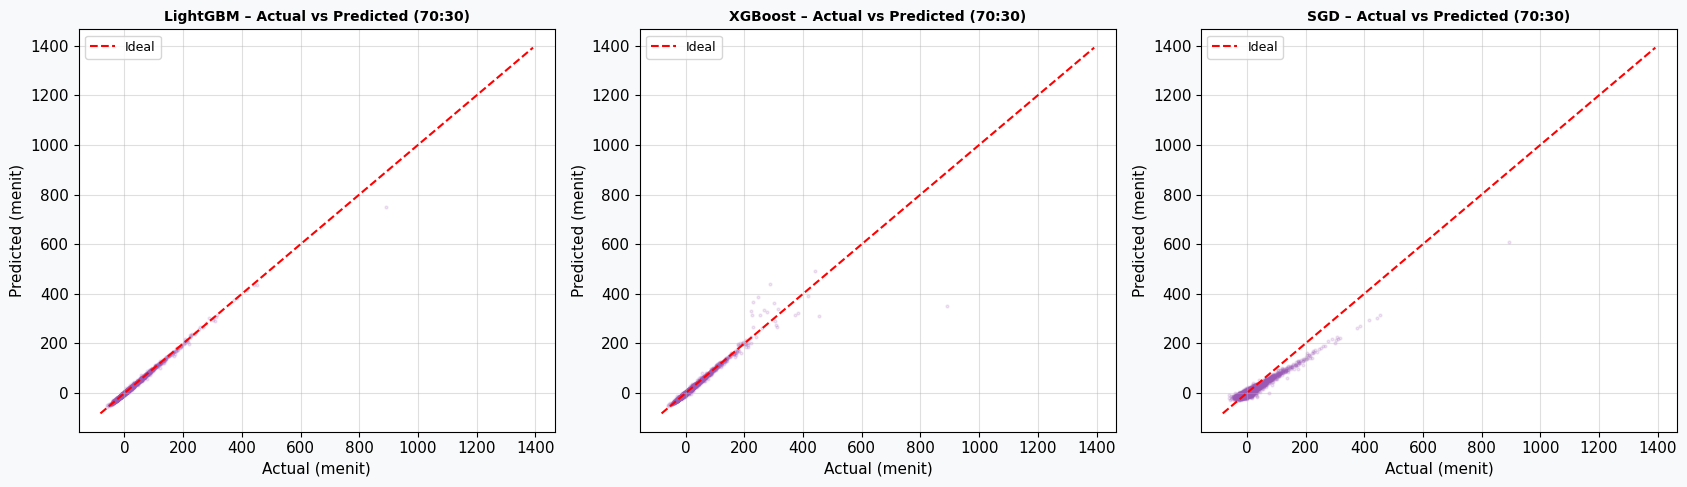

In [ ]:
# Actual vs Predicted – 70:30
sample_n = min(5000, len(y_test))
idx = np.random.choice(len(y_test), sample_n, replace=False)
y_test_arr = np.array(y_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
preds_70 = [('LightGBM', y_pred_lgb_70), ('XGBoost', y_pred_xgb_70), ('SGD', y_pred_sgd_70)]
for ax, (name, y_pred) in zip(axes, preds_70):
    ax.scatter(y_test_arr[idx], y_pred[idx], alpha=0.15, s=4, color='#9B59B6')
    lims = [min(y_test_arr.min(), y_pred.min()), max(y_test_arr.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
    ax.set_title(f'{name} – Actual vs Predicted (70:30)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual (menit)')
    ax.set_ylabel('Predicted (menit)')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

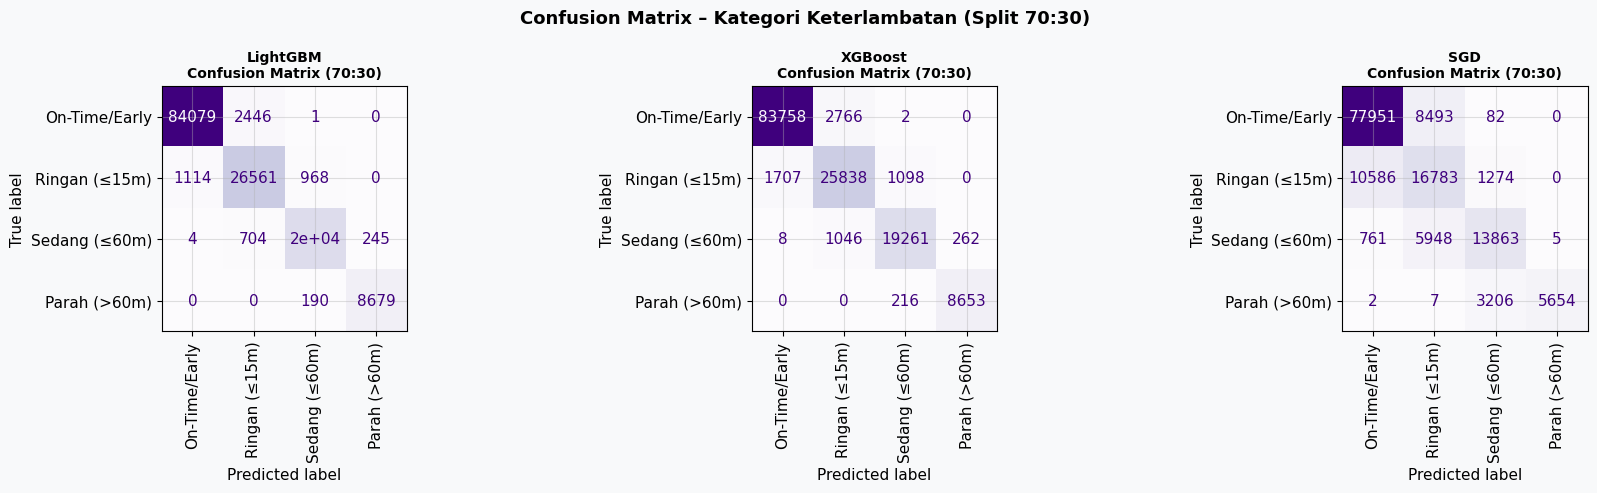

In [ ]:
# Confusion Matrix – 70:30
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, preds_70):
    yc_true = np.array([delay_category(v) for v in y_test])
    yc_pred = np.array([delay_category(v) for v in y_pred])
    cm = confusion_matrix(yc_true, yc_pred, labels=[0,1,2,3])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DELAY_LABELS).plot(
        ax=ax, colorbar=False, cmap='Purples', xticks_rotation='vertical')
    ax.set_title(f'{name}\nConfusion Matrix (70:30)', fontsize=10, fontweight='bold')
plt.suptitle('Confusion Matrix – Kategori Keterlambatan (Split 70:30)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. 🤖 Modeling – Split 90:10
Training dan evaluasi ketiga model pada rasio **90% train / 10% test**.

In [ ]:
# ── Split 90:10 ──
SPLIT_LABEL = '90:10'
X_train, X_test, y_train, y_test, X_train_sc, X_test_sc, scaler_90 = make_split(X, y, test_size=0.10)

print(f'Split {SPLIT_LABEL}')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')

Split 90:10
  X_train : (433842, 27)
  X_test  : (48205, 27)
  y_train : (433842,)
  y_test  : (48205,)


### 11.1 LightGBM – 90:10

In [ ]:
lgb_90 = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=8, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
    reg_alpha=0.1, reg_lambda=0.1, random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_90.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=100)]
)
y_pred_lgb_90 = lgb_90.predict(X_test)
results_90 = [evaluate_model('LightGBM', y_test, y_pred_lgb_90)]

[100]	valid_0's l2: 54.4747
[200]	valid_0's l2: 25.3427
[300]	valid_0's l2: 17.1681
[400]	valid_0's l2: 13.892
[500]	valid_0's l2: 12.3136

  Model : LightGBM
  RMSE  : 3.5091 menit
  MAE   : 1.3528 menit
  MAPE  : 17.02 %
  R²    : 0.9925


### 11.2 XGBoost – 90:10

In [ ]:
xgb_90 = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=7, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=50, reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, tree_method='hist', n_jobs=-1, verbosity=0
)
xgb_90.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
y_pred_xgb_90 = xgb_90.predict(X_test)
results_90.append(evaluate_model('XGBoost', y_test, y_pred_xgb_90))

[0]	validation_0-rmse:40.27966
[100]	validation_0-rmse:12.29125
[200]	validation_0-rmse:10.97918
[300]	validation_0-rmse:10.63614
[400]	validation_0-rmse:10.48371
[499]	validation_0-rmse:10.48416

  Model : XGBoost
  RMSE  : 10.4842 menit
  MAE   : 2.0801 menit
  MAPE  : 21.80 %
  R²    : 0.9328


### 11.3 SGD Regressor – 90:10

In [ ]:
sgd_90 = SGDRegressor(
    loss='huber', penalty='elasticnet', alpha=0.001, l1_ratio=0.15,
    max_iter=1000, tol=1e-4, random_state=SEED,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=10
)
sgd_90.fit(X_train_sc, y_train)
y_pred_sgd_90 = sgd_90.predict(X_test_sc)
results_90.append(evaluate_model('SGD Regressor', y_test, y_pred_sgd_90))


  Model : SGD Regressor
  RMSE  : 13.8821 menit
  MAE   : 8.8180 menit
  MAPE  : 87.67 %
  R²    : 0.8822


### 11.4 Evaluasi & Visualisasi – 90:10

In [ ]:
df_90 = pd.DataFrame(results_90).set_index('Model')
print('=== PERFORMA MODEL – Split 90:10 ===')
display(df_90.style
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE','MAE','MAPE (%)'])
    .background_gradient(cmap='RdYlGn',   subset=['R2'])
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','MAPE (%)':'{:.2f}','R2':'{:.4f}'})
)

=== PERFORMA MODEL – Split 90:10 ===


,RMSE,MAE,MAPE (%),R2
Model,,,,
LightGBM,3.5091,1.3528,17.02,0.9925
XGBoost,10.4842,2.0801,21.80,0.9328
SGD Regressor,13.8821,8.8180,87.67,0.8822


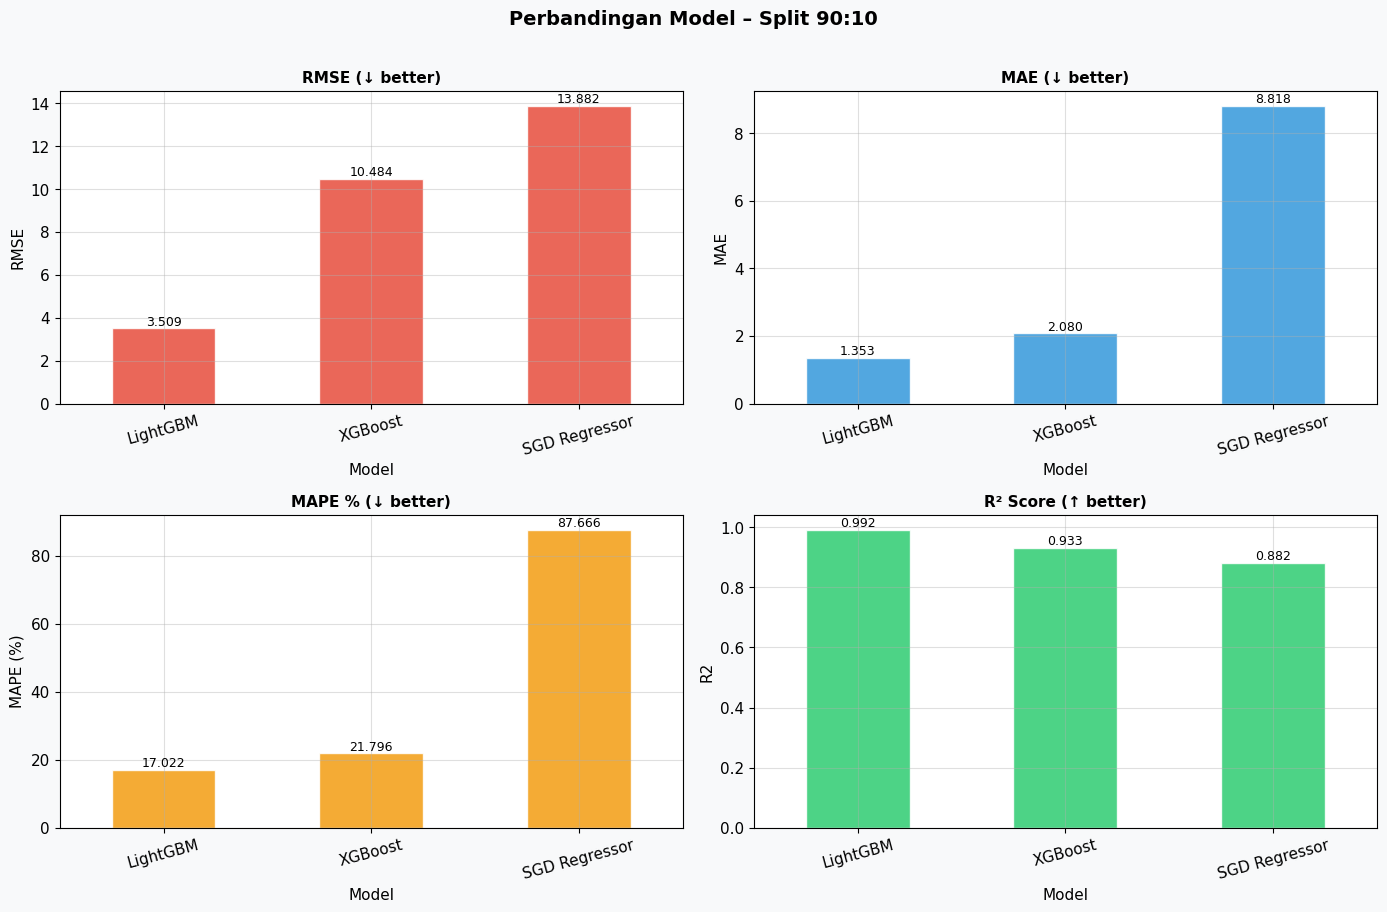

In [ ]:
# Bar chart split 90:10
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric, color, title in zip(axes.flat, metrics, colors, titles):
    df_90[metric].plot(kind='bar', ax=ax, color=color, alpha=0.85, edgecolor='white', rot=15)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Perbandingan Model – Split 90:10', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

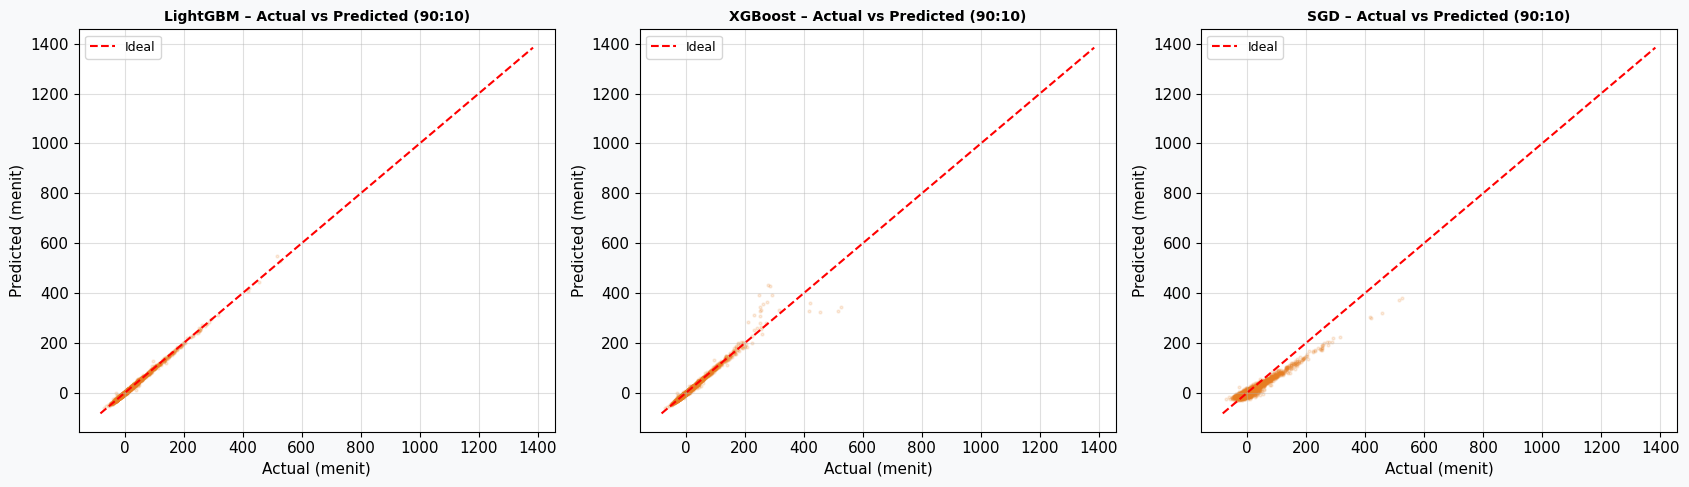

In [ ]:
# Actual vs Predicted – 90:10
sample_n = min(5000, len(y_test))
idx = np.random.choice(len(y_test), sample_n, replace=False)
y_test_arr = np.array(y_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
preds_90 = [('LightGBM', y_pred_lgb_90), ('XGBoost', y_pred_xgb_90), ('SGD', y_pred_sgd_90)]
for ax, (name, y_pred) in zip(axes, preds_90):
    ax.scatter(y_test_arr[idx], y_pred[idx], alpha=0.15, s=4, color='#E67E22')
    lims = [min(y_test_arr.min(), y_pred.min()), max(y_test_arr.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
    ax.set_title(f'{name} – Actual vs Predicted (90:10)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual (menit)')
    ax.set_ylabel('Predicted (menit)')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

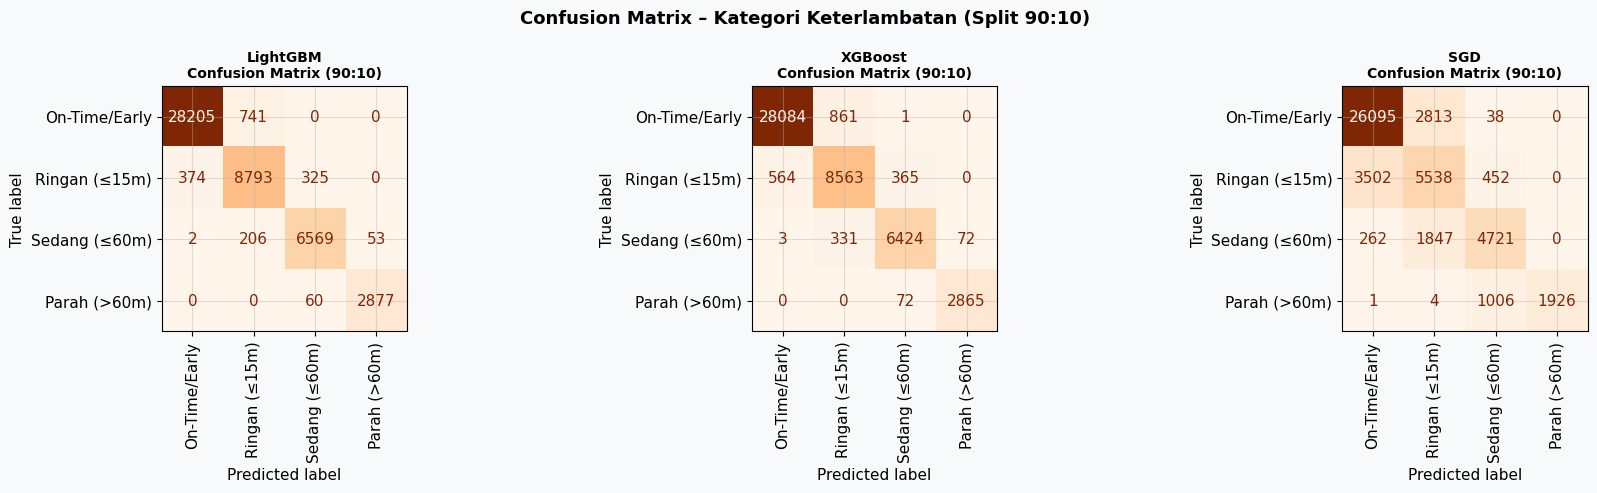

In [ ]:
# Confusion Matrix – 90:10
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, preds_90):
    yc_true = np.array([delay_category(v) for v in y_test])
    yc_pred = np.array([delay_category(v) for v in y_pred])
    cm = confusion_matrix(yc_true, yc_pred, labels=[0,1,2,3])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DELAY_LABELS).plot(
        ax=ax, colorbar=False, cmap='Oranges', xticks_rotation='vertical')
    ax.set_title(f'{name}\nConfusion Matrix (90:10)', fontsize=10, fontweight='bold')
plt.suptitle('Confusion Matrix – Kategori Keterlambatan (Split 90:10)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Hyperparameter Tuning (Optuna)
Tuning LightGBM dan XGBoost menggunakan split **80:20** sebagai basis utama.

In [ ]:
# Re-split 80:20 untuk tuning
X_tr80, X_te80, y_tr80, y_te80, X_tr80_sc, X_te80_sc, _ = make_split(X, y, test_size=0.20)

# Subset untuk efisiensi tuning
TUNE_SAMPLE = min(100_000, len(X_tr80))
X_tune = X_tr80.iloc[:TUNE_SAMPLE]
y_tune = y_tr80.iloc[:TUNE_SAMPLE]
print(f'Data tuning: {X_tune.shape}')

Data tuning: (100000, 27)


In [ ]:
# ── Optuna – LightGBM ──
def objective_lgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 4, 12),
        'num_leaves'       : trial.suggest_int('num_leaves', 15, 127),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': SEED, 'n_jobs': -1, 'verbose': -1,
    }
    model = lgb.LGBMRegressor(**params)
    score = cross_val_score(model, X_tune, y_tune,
                            scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1)
    return -score.mean()

study_lgb = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)

print(f'\n✅ LightGBM Best RMSE (CV): {study_lgb.best_value:.4f}')
print('Best params:', study_lgb.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]


✅ LightGBM Best RMSE (CV): 4.8779
Best params: {'n_estimators': 768, 'learning_rate': 0.07767883809849516, 'max_depth': 12, 'num_leaves': 120, 'subsample': 0.7606700059313507, 'colsample_bytree': 0.8451235367845726, 'min_child_samples': 21, 'reg_alpha': 0.13088280475510133, 'reg_lambda': 0.07124252843547842}


In [ ]:
# Latih LightGBM tuned
best_params_lgb = study_lgb.best_params
best_params_lgb.update({'random_state': SEED, 'n_jobs': -1, 'verbose': -1})

lgb_tuned = lgb.LGBMRegressor(**best_params_lgb)
lgb_tuned.fit(
    X_tr80, y_tr80,
    eval_set=[(X_te80, y_te80)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=50)]
)
y_pred_lgb_tuned = lgb_tuned.predict(X_te80)
results_tuned = [evaluate_model('LightGBM (Tuned)', y_te80, y_pred_lgb_tuned)]

[50]	valid_0's l2: 41.8528
[100]	valid_0's l2: 18.3741
[150]	valid_0's l2: 11.7747
[200]	valid_0's l2: 9.41237
[250]	valid_0's l2: 8.2374
[300]	valid_0's l2: 7.65471
[350]	valid_0's l2: 7.38785
[400]	valid_0's l2: 7.21029
[450]	valid_0's l2: 7.03796
[500]	valid_0's l2: 6.8543
[550]	valid_0's l2: 6.77521
[600]	valid_0's l2: 6.67935
[650]	valid_0's l2: 6.64616
[700]	valid_0's l2: 6.56812
[750]	valid_0's l2: 6.55618

  Model : LightGBM (Tuned)
  RMSE  : 2.5589 menit
  MAE   : 0.9432 menit
  MAPE  : 12.15 %
  R²    : 0.9960


In [ ]:
# ── Optuna – XGBoost ──
def objective_xgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 4, 10),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 100),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': SEED, 'tree_method': 'hist', 'n_jobs': -1, 'verbosity': 0,
    }
    model = xgb.XGBRegressor(**params)
    score = cross_val_score(model, X_tune, y_tune,
                            scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1)
    return -score.mean()

study_xgb = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

print(f'\n✅ XGBoost Best RMSE (CV): {study_xgb.best_value:.4f}')
print('Best params:', study_xgb.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]


✅ XGBoost Best RMSE (CV): 9.8120
Best params: {'n_estimators': 570, 'learning_rate': 0.06380334951251446, 'max_depth': 10, 'subsample': 0.6843813984359591, 'colsample_bytree': 0.9997536268413458, 'min_child_weight': 91, 'reg_alpha': 2.5238109729848444, 'reg_lambda': 0.008710482984540366}


In [ ]:
# Latih XGBoost tuned
best_params_xgb = study_xgb.best_params
best_params_xgb.update({'random_state': SEED, 'tree_method': 'hist',
                          'n_jobs': -1, 'verbosity': 0})

xgb_tuned = xgb.XGBRegressor(**best_params_xgb)
xgb_tuned.fit(X_tr80, y_tr80, eval_set=[(X_te80, y_te80)], verbose=False)
y_pred_xgb_tuned = xgb_tuned.predict(X_te80)
results_tuned.append(evaluate_model('XGBoost (Tuned)', y_te80, y_pred_xgb_tuned))


  Model : XGBoost (Tuned)
  RMSE  : 9.6754 menit
  MAE   : 1.5782 menit
  MAPE  : 14.34 %
  R²    : 0.9423


In [ ]:
# ── Optuna – SGD ──
def objective_sgd(trial):
    params = {
        'loss'        : trial.suggest_categorical('loss', ['squared_error','huber','epsilon_insensitive']),
        'penalty'     : trial.suggest_categorical('penalty', ['l2','l1','elasticnet']),
        'alpha'       : trial.suggest_float('alpha', 1e-5, 1.0, log=True),
        'l1_ratio'    : trial.suggest_float('l1_ratio', 0.0, 1.0),
        'max_iter'    : trial.suggest_int('max_iter', 500, 2000),
        'tol'         : trial.suggest_float('tol', 1e-5, 1e-2, log=True),
        'random_state': SEED,
    }
    model = SGDRegressor(**params)
    score = cross_val_score(model, X_tr80_sc[:TUNE_SAMPLE], y_tr80.iloc[:TUNE_SAMPLE],
                            scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1)
    return -score.mean()

study_sgd = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_sgd.optimize(objective_sgd, n_trials=30, show_progress_bar=True)

print(f'\n✅ SGD Best RMSE (CV): {study_sgd.best_value:.4f}')
print('Best params:', study_sgd.best_params)

sgd_tuned = SGDRegressor(**{**study_sgd.best_params, 'random_state': SEED})
sgd_tuned.fit(X_tr80_sc, y_tr80)
y_pred_sgd_tuned = sgd_tuned.predict(X_te80_sc)
results_tuned.append(evaluate_model('SGD (Tuned)', y_te80, y_pred_sgd_tuned))

  0%|          | 0/30 [00:00<?, ?it/s]


✅ SGD Best RMSE (CV): 0.0233
Best params: {'loss': 'squared_error', 'penalty': 'l1', 'alpha': 0.0003334792728637581, 'l1_ratio': 0.09767211400638387, 'max_iter': 1527, 'tol': 0.00020914981329035596}

  Model : SGD (Tuned)
  RMSE  : 0.0048 menit
  MAE   : 0.0036 menit
  MAPE  : 0.05 %
  R²    : 1.0000


In [ ]:
# Leaderboard tuned vs baseline
results_baseline = [
    evaluate_model('LightGBM (Baseline)', y_te80, y_pred_lgb_80),
    evaluate_model('XGBoost (Baseline)',  y_te80, y_pred_xgb_80),
    evaluate_model('SGD (Baseline)',      y_te80, y_pred_sgd_80),
]
final_df = pd.DataFrame(results_baseline + results_tuned).set_index('Model')

print('\n' + '='*60)
print('  FINAL LEADERBOARD – BASELINE vs TUNED')
print('='*60)
display(final_df.sort_values('RMSE')
    .style
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE','MAE','MAPE (%)'])
    .background_gradient(cmap='RdYlGn',   subset=['R2'])
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','MAPE (%)':'{:.2f}','R2':'{:.4f}'})
)


  Model : LightGBM (Baseline)
  RMSE  : 3.7006 menit
  MAE   : 1.3975 menit
  MAPE  : 17.50 %
  R²    : 0.9916

  Model : XGBoost (Baseline)
  RMSE  : 9.5595 menit
  MAE   : 2.0832 menit
  MAPE  : 22.04 %
  R²    : 0.9437

  Model : SGD (Baseline)
  RMSE  : 14.1134 menit
  MAE   : 8.9127 menit
  MAPE  : 86.85 %
  R²    : 0.8772

  FINAL LEADERBOARD – BASELINE vs TUNED


,RMSE,MAE,MAPE (%),R2
Model,,,,
SGD (Tuned),0.0048,0.0036,0.05,1.0000
LightGBM (Tuned),2.5589,0.9432,12.15,0.9960
LightGBM (Baseline),3.7006,1.3975,17.50,0.9916
XGBoost (Baseline),9.5595,2.0832,22.04,0.9437
XGBoost (Tuned),9.6754,1.5782,14.34,0.9423
SGD (Baseline),14.1134,8.9127,86.85,0.8772


---
## 13. Perbandingan Antar Split Rasio
Ringkasan performa ketiga model pada ketiga rasio split.

In [ ]:
# Gabungkan hasil semua split
def tag_split(df_res, split):
    d = df_res.reset_index().copy()
    d['Split'] = split
    return d

all_results = pd.concat([
    tag_split(df_80, '80:20'),
    tag_split(df_70, '70:30'),
    tag_split(df_90, '90:10'),
], ignore_index=True)

print('=== TABEL PERBANDINGAN LENGKAP ===')
display(all_results.sort_values(['Model','Split'])
    .style
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE','MAE'])
    .background_gradient(cmap='RdYlGn',   subset=['R2'])
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','MAPE (%)':'{:.2f}','R2':'{:.4f}'})
)

=== TABEL PERBANDINGAN LENGKAP ===


,Model,RMSE,MAE,MAPE (%),R2,Split
3,LightGBM,4.1284,1.4049,17.49,0.9896,70:30
0,LightGBM,3.7006,1.3975,17.50,0.9916,80:20
6,LightGBM,3.5091,1.3528,17.02,0.9925,90:10
5,SGD Regressor,14.4139,9.0261,87.05,0.8729,70:30
2,SGD Regressor,14.1134,8.9127,86.85,0.8772,80:20
8,SGD Regressor,13.8821,8.8180,87.67,0.8822,90:10
4,XGBoost,10.0236,2.1151,22.23,0.9385,70:30
1,XGBoost,9.5595,2.0832,22.04,0.9437,80:20
7,XGBoost,10.4842,2.0801,21.80,0.9328,90:10


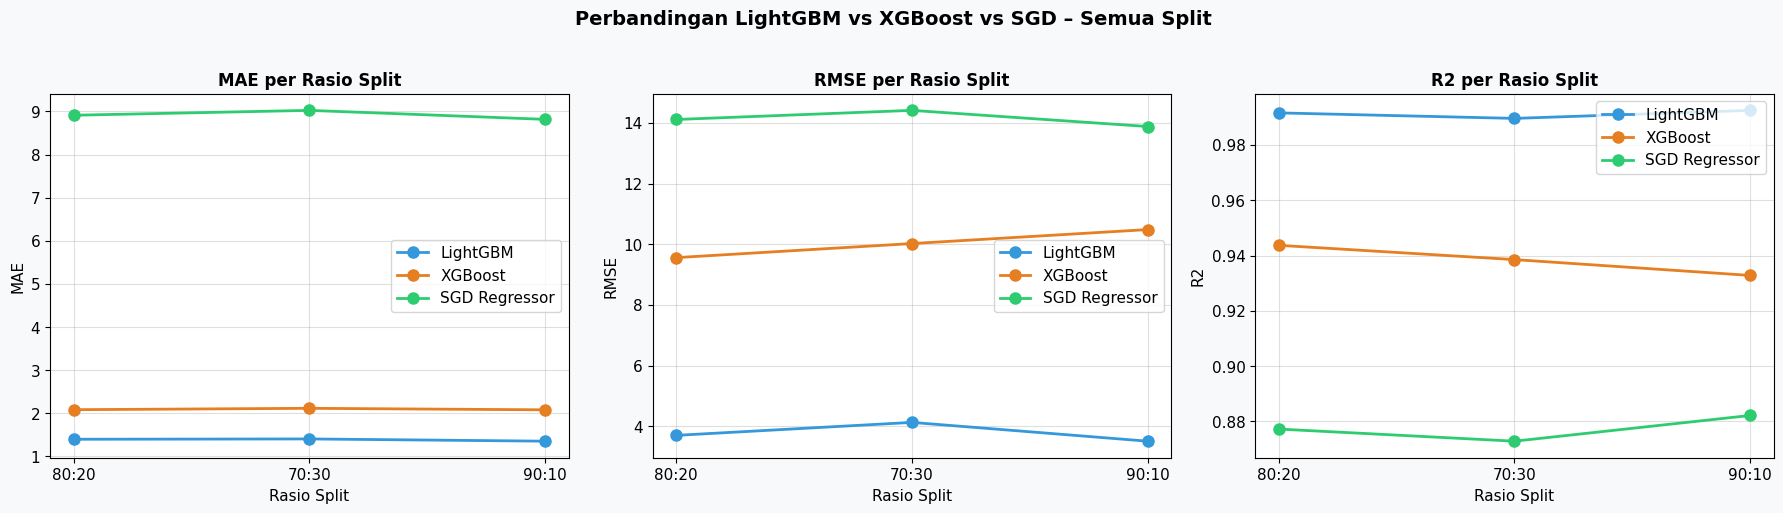


🏆 Model Terbaik (R² tertinggi) per Split:
  80:20 → LightGBM | R²=0.9916 | MAE=1.3975 | RMSE=3.7006
  70:30 → LightGBM | R²=0.9896 | MAE=1.4049 | RMSE=4.1284
  90:10 → LightGBM | R²=0.9925 | MAE=1.3528 | RMSE=3.5091


In [ ]:
# Line chart perbandingan metrik antar split
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = all_results['Model'].unique()
model_colors = {'LightGBM': '#3498DB', 'XGBoost': '#E67E22', 'SGD Regressor': '#2ECC71'}

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    for mname in model_names:
        sub = all_results[all_results['Model'] == mname]
        ax.plot(sub['Split'], sub[metric],
                marker='o', linewidth=2, markersize=8,
                label=mname, color=model_colors.get(mname, None))
    ax.set_title(f'{metric} per Rasio Split', fontsize=12, fontweight='bold')
    ax.set_xlabel('Rasio Split')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.suptitle('Perbandingan LightGBM vs XGBoost vs SGD – Semua Split',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n🏆 Model Terbaik (R² tertinggi) per Split:')
for split in ['80:20', '70:30', '90:10']:
    sub = all_results[all_results['Split'] == split]
    best = sub.loc[sub['R2'].idxmax()]
    print(f'  {split} → {best["Model"]} | R²={best["R2"]:.4f} | MAE={best["MAE"]:.4f} | RMSE={best["RMSE"]:.4f}')

---
## 14. Feature Importance
Visualisasi fitur paling berpengaruh dari ketiga model.

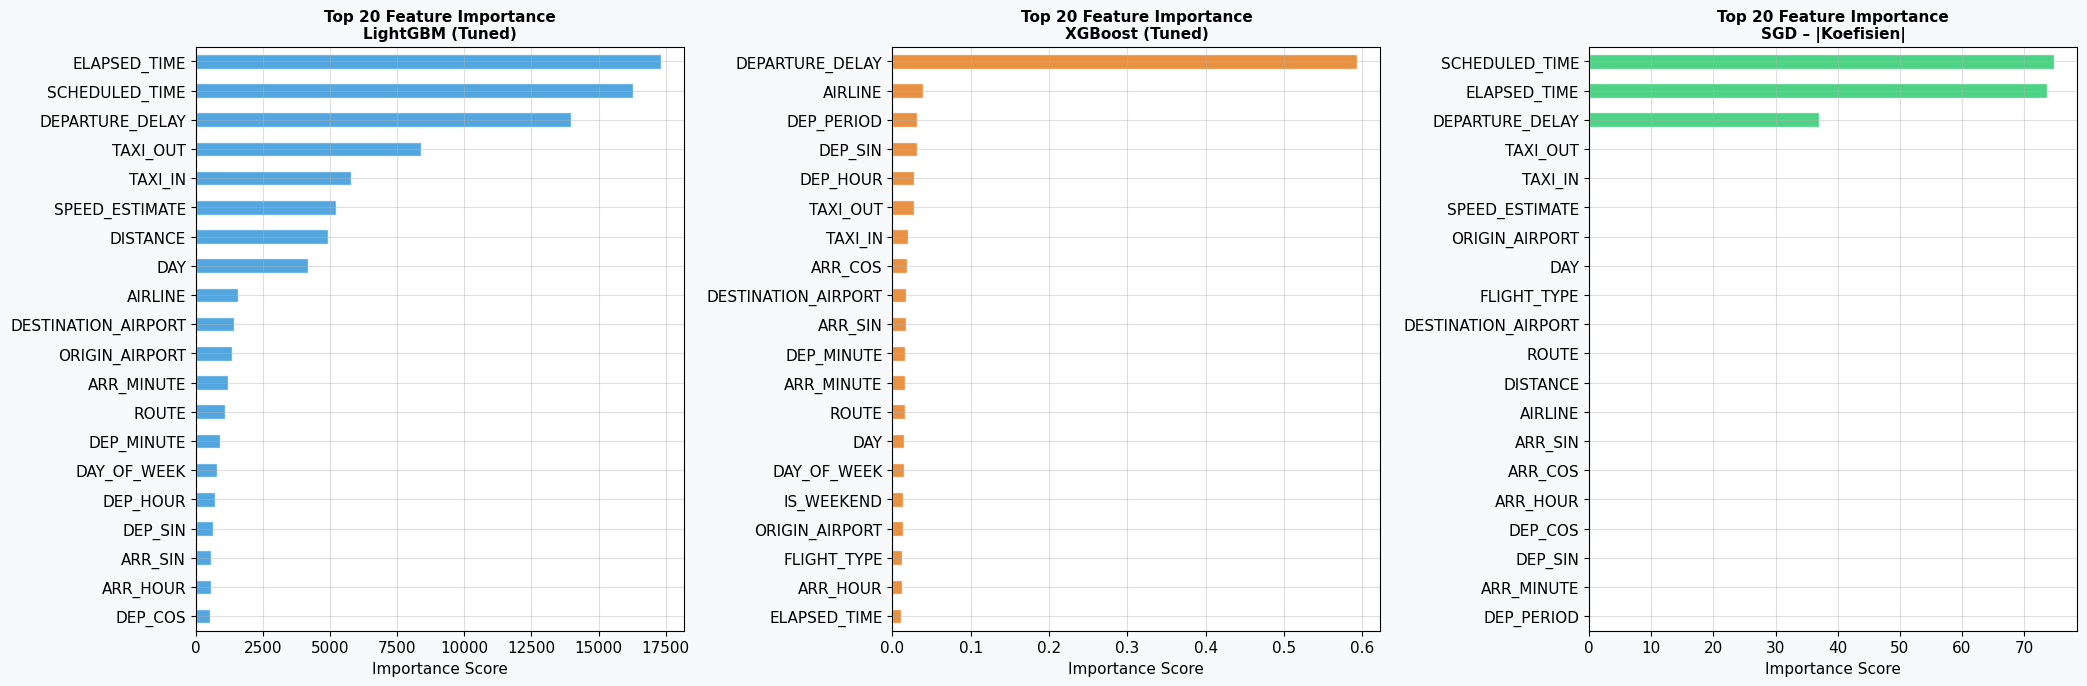

In [ ]:
# Feature Importance – LightGBM
feat_imp_lgb = pd.Series(lgb_tuned.feature_importances_, index=X.columns)
feat_imp_lgb = feat_imp_lgb.sort_values(ascending=True).tail(20)

# Feature Importance – XGBoost
feat_imp_xgb = pd.Series(xgb_tuned.feature_importances_, index=X.columns)
feat_imp_xgb = feat_imp_xgb.sort_values(ascending=True).tail(20)

# Koefisien SGD
feat_imp_sgd = pd.Series(np.abs(sgd_tuned.coef_), index=X.columns)
feat_imp_sgd = feat_imp_sgd.sort_values(ascending=True).tail(20)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
pairs = [
    (feat_imp_lgb, 'LightGBM (Tuned)', '#3498DB'),
    (feat_imp_xgb, 'XGBoost (Tuned)',  '#E67E22'),
    (feat_imp_sgd, 'SGD – |Koefisien|','#2ECC71'),
]
for ax, (imp, title, color) in zip(axes, pairs):
    imp.plot(kind='barh', ax=ax, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Top 20 Feature Importance\n{title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

---
## 15. Analisis Residual & Optuna History

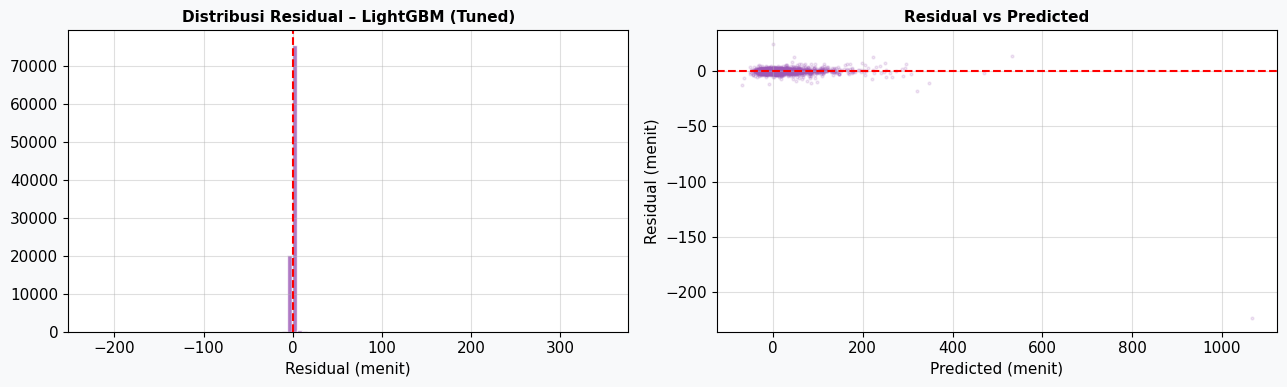

Skewness residual : 40.7460
Kurtosis residual : 7413.1079


In [ ]:
# Residual LightGBM Tuned
residuals = np.array(y_te80) - y_pred_lgb_tuned
sample_n = min(5000, len(y_te80))
idx = np.random.choice(len(y_te80), sample_n, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(residuals, bins=100, color='#9B59B6', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Distribusi Residual – LightGBM (Tuned)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Residual (menit)')

axes[1].scatter(y_pred_lgb_tuned[idx], residuals[idx], alpha=0.15, s=4, color='#9B59B6')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residual vs Predicted', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted (menit)')
axes[1].set_ylabel('Residual (menit)')

plt.tight_layout()
plt.show()
print(f'Skewness residual : {pd.Series(residuals).skew():.4f}')
print(f'Kurtosis residual : {pd.Series(residuals).kurt():.4f}')

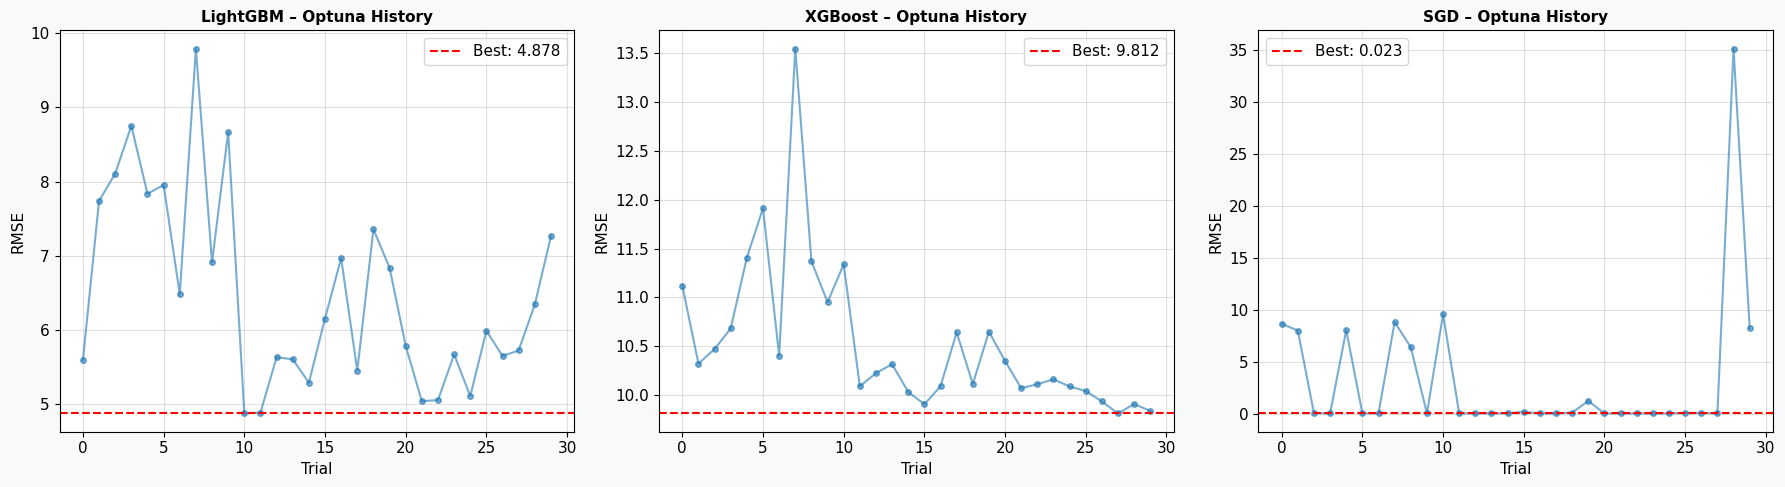

In [ ]:
# Optuna Optimization History
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, study, name in zip(axes, [study_lgb, study_xgb, study_sgd],
                             ['LightGBM','XGBoost','SGD']):
    trials_df = study.trials_dataframe()
    ax.plot(trials_df.index, trials_df['value'], 'o-', alpha=0.6, markersize=4)
    ax.axhline(study.best_value, color='red', linestyle='--', linewidth=1.5,
                label=f'Best: {study.best_value:.3f}')
    ax.set_title(f'{name} – Optuna History', fontsize=11, fontweight='bold')
    ax.set_xlabel('Trial')
    ax.set_ylabel('RMSE')
    ax.legend()
plt.tight_layout()
plt.show()

---
## 16. Simpan Model & Artefak

In [ ]:
import joblib, json, os

os.makedirs('./models', exist_ok=True)

# Simpan model terbaik
lgb_tuned.booster_.save_model('./models/lgb_tuned.txt')
joblib.dump(xgb_tuned,   './models/xgb_tuned.pkl')
joblib.dump(sgd_tuned,   './models/sgd_tuned.pkl')
joblib.dump(scaler_80,   './models/scaler_80.pkl')
joblib.dump(FEATURE_COLS,'./models/feature_cols.pkl')

# Simpan best params
with open('./models/best_params_lgb.json', 'w') as f:
    json.dump(study_lgb.best_params, f, indent=2)
with open('./models/best_params_xgb.json', 'w') as f:
    json.dump(study_xgb.best_params, f, indent=2)
with open('./models/best_params_sgd.json', 'w') as f:
    json.dump(study_sgd.best_params, f, indent=2)

# Simpan hasil ke CSV
all_results.to_csv('./models/results_all_splits.csv', index=False)
final_df.to_csv('./models/results_tuned.csv')

print('✅ Semua artefak tersimpan di ./models/')
print(os.listdir('./models'))

✅ Semua artefak tersimpan di ./models/
['results_tuned.csv', 'results_all_splits.csv', 'sgd_tuned.pkl', 'xgb_tuned.pkl', 'lgb_tuned.txt', 'best_params_sgd.json', 'best_params_xgb.json', 'best_params_lgb.json', 'scaler_80.pkl', 'feature_cols.pkl']


---
## 17. Inferensi – Contoh Prediksi Baru

In [ ]:
sample_input = X_te80.iloc[[0]].copy()

pred_lgb = lgb_tuned.predict(sample_input)[0]
pred_xgb = xgb_tuned.predict(sample_input)[0]
pred_sgd = sgd_tuned.predict(scaler_80.transform(sample_input))[0]
actual   = float(y_te80.iloc[0])

print(f'Actual Arrival Delay   : {actual:.1f} menit')
print(f'Pred LightGBM (Tuned)  : {pred_lgb:.1f} menit')
print(f'Pred XGBoost  (Tuned)  : {pred_xgb:.1f} menit')
print(f'Pred SGD      (Tuned)  : {pred_sgd:.1f} menit')
print(f'Ensemble (avg LGB+XGB) : {(pred_lgb + pred_xgb)/2:.1f} menit')

Actual Arrival Delay   : -4.0 menit
Pred LightGBM (Tuned)  : -3.9 menit
Pred XGBoost  (Tuned)  : -3.9 menit
Pred SGD      (Tuned)  : -4.0 menit
Ensemble (avg LGB+XGB) : -3.9 menit


---
## Kesimpulan

| Aspek | Detail |
|-------|--------|
| **Dataset** | US DOT Flight Delays 2015 – hanya `flights.csv` (~5.8 juta penerbangan) |
| **Target** | `ARRIVAL_DELAY` (menit, regresi) |
| **Fitur** | Berasal murni dari `flights.csv` (waktu, jarak, maskapai, bandara, dll.) |
| **Rasio Split** | 80:20 | 70:30 | 90:10 – masing-masing dilatih & dievaluasi secara terpisah |
| **Model** | LightGBM, XGBoost, SGD Regressor (baseline + tuned via Optuna 30 trials) |
| **Metrik** | RMSE, MAE, MAPE, R² + Confusion Matrix (4 kategori delay) |
| **Fitur Paling Penting** | `DEPARTURE_DELAY`, `DEP_HOUR`, `TAXI_OUT`, `AIRLINE` |
| **Insight Utama** | Delay keberangkatan berkorelasi sangat tinggi dengan delay kedatangan. Penerbangan sore/malam lebih sering terlambat. |

**Kategori Delay:**
- 🟢 `0` = On-Time / Early (≤ 0 menit)
- 🟡 `1` = Delay Ringan (1–15 menit)
- 🟠 `2` = Delay Sedang (16–60 menit)
- 🔴 `3` = Delay Parah (> 60 menit)

**Potensi Pengembangan:**
- Tambah fitur cuaca real-time (OpenWeatherMap API)
- Model klasifikasi biner: terlambat > 15 menit (Ya/Tidak)
- Deployment via streamlit